<div style="display:block;width:100%;margin:auto;" direction=rtl align=center>
    <div style="width:100%;margin:20px auto;display:block;background-color:#fff0;" align=center>
        <table style="border-style:hidden;border-collapse:collapse;">
            <tr>
                <td style="border: none!important;">
                    <img width=130 align=right src="https://i.ibb.co/yXKQmtZ/logo1.png" style="margin:0;" />
                </td>
                <td style="text-align:center;border: none!important;">
                    <h1 align=center><font size=5 color="#025F5F"><b>Deep Generative Models</b><br><br>Project 1: Variational Autoencoders (VAEs)</font></h1>
                </td>
                <td style="border: none!important;">
                    <img width=170 align=left src="https://i.ibb.co/wLjqFkw/logo2.png" style="margin:0;" />
                </td>
            </tr>
        </table>
    </div>
</div>

# 📑 Table of Contents

## Part I: Introduction & Theory
1. [Project Overview](#1.-Project-Overview)
2. [Theoretical Background](#Theoretical-Background)
3. [Mathematical Foundations](#Mathematical-Foundations)

## Part II: Implementation Setup
4. [Setup and Dependencies](#Section-1:-Setup-and-Dependencies)
5. [Data Acquisition](#Section-2:-Data-Acquisition)
6. [Data Preprocessing](#Section-3:-Data-Preprocessing-and-Loading)
7. [Data Visualization](#Section-4:-Data-Visualization)

## Part III: Model Architecture
8. [Model Architecture Definition](#Section-5:-Model-Architecture-and-Definition)
9. [Architecture Visualization](#Architecture-Visualization)
10. [Loss Function Theory](#Section-6:-Loss-Function)
11. [Loss Function Implementation](#Loss-Function-Implementation)

## Part IV: Training
12. [Training Configuration](#Section-7:-Training-Configuration)
13. [Training Process Visualization](#Training-Process)
14. [Loss Analysis](#Training-Loss-Analysis)

## Part V: Evaluation & Analysis
15. [Image Reconstruction](#Section-8:-Evaluation---Image-Reconstruction)
16. [Reconstruction Analysis](#Reconstruction-Analysis)
17. [Image Generation](#Section-10:-Image-Generation)
18. [Generation Analysis](#Generation-Analysis)
19. [Latent Space Exploration](#Latent-Space-Exploration)

## Part VI: Advanced Concepts
20. [Reparameterization Trick](#Reparameterization-Trick-Demonstration)
21. [ELBO Visualization](#ELBO-Visualization)
22. [Latent Space Statistics](#Latent-Space-Statistics)
23. [Interpolation Techniques](#Advanced-Interpolation)
24. [Class Separation Analysis](#Class-Separation)

## Part VII: Summary & Conclusions
25. [Feature Summary](#Comprehensive-Feature-Summary)
26. [Conclusion](#Section-14:-Conclusion-and-Future-Work)

---


---

## Project Information

**Name:** Mohammad Taha Majlesi  
**Student ID:** 8100101504  
**Course:** Deep Generative Models  
**Instructor:** Dr. Tavassoli Pour  
**University:** University of Tehran

---


# Project 1: Variational Autoencoders (VAEs)

## Abstract

This project explores and implements **Variational Autoencoders (VAEs)**, a powerful class of generative models that enable learning probabilistic representations of data. A convolutional VAE is implemented for compressing and reconstructing images, examining the mathematical foundations of Variational Inference.

## 1. Project Overview

### 1.1 Objectives

1. **Master Variational Inference**
   - Understand how to optimize the Evidence Lower Bound (ELBO) to learn latent distributions that preserve data structure

2. **Implement the Reparameterization Trick**
   - Learn the reparameterization trick that enables gradient-based optimization of stochastic latent variables

3. **Build Encoder-Decoder Architectures**
   - Design convolutional networks for encoding images into latent spaces and decoding latent vectors back to images

4. **Balance Reconstruction and Regularization**
   - Optimize the trade-off between reconstruction accuracy and latent space regularization through KL divergence

5. **Explore Latent Manifolds**
   - Analyze and manipulate learned latent spaces for interpolation, generation, and feature disentanglement

### 1.2 Technical Specifications

| Component | Description |
|-----------|-------------|
| **Architecture** | Convolutional encoder with multiple layers for hierarchical feature extraction, paired with a symmetric transposed convolutional decoder |
| **Latent Space** | Probabilistic representation using mean and variance vectors, regularized to follow a standard normal distribution |
| **Loss Function** | Combination of Reconstruction Loss (MSE) and KL Divergence to ensure accuracy and generalizability |
| **Training Dynamics** | Monitoring the balance between reconstruction quality and latent space structure during optimization |

### 1.3 Expected Outcomes

Upon completion, the implementation will demonstrate:

- Compression of high-dimensional images into low-dimensional latent representations while preserving essential features
- Generation of new images by sampling from the learned latent distribution
- Smooth interpolation between different data points in the latent space
- Analysis of the structure of learned representations using dimensionality reduction techniques
- Understanding of the theoretical foundations connecting VAEs to probabilistic graphical models

### 1.4 Significance

This project provides a solid foundation in generative modeling that bridges traditional autoencoders with probabilistic inference, setting the stage for more advanced techniques such as GANs and Diffusion Models.

# Theoretical Background: Variational Autoencoders

## 1. Introduction

**Variational Autoencoders (VAEs)** are a class of generative models that enable efficient encoding and decoding of data by learning a latent representation. Unlike traditional autoencoders, VAEs impose a probabilistic structure on the latent space, allowing for meaningful generation and interpolation of new data samples. These models are particularly effective in tasks such as image generation, anomaly detection, and dimensionality reduction.

---

## 1. VAE Architecture

A VAE consists of two main components:

### 1.1 Encoder (Recognition Model)
- Maps input data to a latent space
- Produces parameters of a probability distribution (typically mean and log variance of a Gaussian distribution)

### 1.2 Decoder (Generative Model)
- Generates data by sampling from the latent space distribution
- Maps latent vectors back to the data space

## 2. Probabilistic Modeling and Latent Space

### 2.1 Key Innovation of VAEs

The primary innovation of VAEs is the introduction of a **continuous and smooth latent space**, characterized by a predefined prior distribution (usually a standard normal distribution). This probabilistic approach ensures that regions in the latent space correspond to meaningful data variations.

### 2.2 Evidence Lower Bound (ELBO)

The training objective of a VAE is to maximize the likelihood of the data while keeping the latent space distribution close to the prior. This is achieved by maximizing the **Evidence Lower Bound (ELBO)**:

$$
\mathcal{L}(\theta, \phi; \mathbf{x}) = \mathbb{E}_{q_\phi(\mathbf{z}|\mathbf{x})} [\log p_\theta(\mathbf{x}|\mathbf{z})] - \text{KL}(q_\phi(\mathbf{z}|\mathbf{x}) || p(\mathbf{z}))
$$

#### 2.2.1 Objective Function Components:

1. **Reconstruction Loss** ($\mathbb{E}_{q_\phi(\mathbf{z}|\mathbf{x})} [\log p_\theta(\mathbf{x}|\mathbf{z})]$)
   - Encourages the decoder to reconstruct the input data accurately from latent variables
   - Measures reconstruction quality

2. **Kullback-Leibler (KL) Divergence** ($\text{KL}(q_\phi(\mathbf{z}|\mathbf{x}) || p(\mathbf{z}))$)
   - Regularizes the encoder to keep the learned latent distribution close to the prior distribution
   - Ensures latent space structure

## 3. VAE Architecture in This Project

In this project, the VAE is designed to handle image data, specifically leveraging convolutional layers to capture spatial hierarchies.

### 3.1 Encoder Network

| Component | Description |
|-----------|-------------|
| **Convolutional Layers** | Four convolutional layers progressively reduce spatial dimensions while increasing feature depth. This hierarchy extracts low to high-level features in images |
| **Activation Functions** | LeakyReLU introduces non-linearity, enabling the network to learn complex patterns |
| **BatchNorm and Dropout Layers** | For training stability and preventing overfitting |
| **Fully Connected Transformation** | Convolutional layer outputs are flattened and passed through a fully connected layer to obtain a hidden representation of size `hidden_dim` |
| **Latent Variables** | Two separate fully connected layers generate mean (`latent_mean`) and log variance (`latent_logvar`) vectors of the latent space distribution |

### 3.2 Reparameterization Trick

To enable gradient backpropagation through stochastic sampling, the reparameterization trick is used:

**Steps:**

1. **Sample Epsilon**: A sample $\epsilon$ is drawn from a standard normal distribution

2. **Compute Latent Vector**:
   $$
   \mathbf{z} = \boldsymbol{\mu} + \boldsymbol{\sigma} \odot \epsilon, \quad \text{where} \quad \boldsymbol{\sigma} = \exp\left(0.5 \times \logvar\right)
   $$

This separates the randomness from the deterministic parameters, allowing gradients to flow through $\boldsymbol{\mu}$ and $\boldsymbol{\sigma}$.

### 3.3 Decoder Network

| Component | Description |
|-----------|-------------|
| **Input Transformation** | A fully connected layer transforms the latent vector to an appropriate shape for convolutional decoding |
| **Transposed Convolutional Layers** | Four transposed convolutional layers progressively increase spatial dimensions, reconstructing the image |
| **Activation Functions** | LeakyReLU is used after each layer, except the last |
| **Output Layer** | Tanh activation function scales output pixel values to the range $[-1, 1]$, matching the normalized input range |

## 4. Loss Function

The loss function combines two terms:

### 4.1 Reconstruction Loss
- Implemented using **Mean Squared Error (MSE)** between original and reconstructed images
- Encourages the decoder to produce images similar to the input
- Measures reconstruction quality

### 4.2 KL Divergence Loss
- Measures the divergence between the learned latent distribution $q(\mathbf{z}|\mathbf{x})$ and the prior $p(\mathbf{z})$ (standard normal distribution)
- Encourages the latent space to be continuous and ensures smooth interpolation between points

**Total Loss:**
$$
\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{recon}} + \mathcal{L}_{\text{KL}}
$$

## 5. Training Process

### 5.1 Initialization
- Model and optimizer (e.g., Adam optimizer with specified learning rate) are initialized
- Loss lists are prepared to track training and validation losses over epochs

### 5.2 Epoch Loop

#### 5.2.1 Training Phase
1. Model is set to training mode
2. For each batch in training data:
   - Input images are passed through the encoder to obtain latent mean and log variance
   - Latent vectors are sampled using the reparameterization trick
   - Decoder reconstructs images from latent vectors
   - Total loss is computed and backpropagation is performed
   - Optimizer updates model parameters
3. Training losses are accumulated and averaged

#### 5.2.2 Validation Phase
1. Model is set to evaluation mode
2. Gradients are not computed to save memory
3. Validation data is passed through the model to compute validation loss

#### 5.2.3 Progress Logging
- Training and validation losses are printed for each epoch to monitor progress

## 6. Applications and Results

### 6.1 Image Reconstruction

**Purpose:** Evaluate the VAE's ability to compress and reconstruct input images

**Method:**
- Original and reconstructed images are displayed side by side
- Visual inspection helps assess reconstruction quality

**Expected Outcome:**
- The VAE should produce images that preserve the main features of the originals
- Reconstructed images may be smoother due to latent space regularization

### 6.2 Image Generation

**Purpose:** Generate new, unseen images by sampling from the latent space

**Method:**
- Random latent vectors are sampled from the standard normal distribution
- These vectors are passed through the decoder to generate images

**Expected Outcome:**
- Generated images reflect the data distribution learned during training
- They may exhibit variations and combinations of features present in the training data

### 6.3 Latent Space Exploration

**Purpose:** Understand and manipulate the learned latent space

**Method:**
- Mean latent vectors are computed for different classes or attributes
- A direction in latent space is defined by subtracting mean vectors (e.g., $\delta = \mu_{\text{class1}} - \mu_{\text{class2}}$)
- Interpolation is performed along this direction by adding scaled versions of $\delta$ to a sample latent vector

**Expected Outcome:**
- Changes in generated images correspond to attribute differences between classes
- Demonstrates feature disentanglement in the latent space

## 7. Conclusion

The Variational Autoencoder implemented in this project effectively learns a compressed representation of image data, balancing reconstruction fidelity with latent space regularization. By training the VAE, we achieve:

- **Efficient Data Compression**: The encoder reduces high-dimensional images to lower-dimensional latent vectors
- **Generative Modeling**: The decoder generates realistic images from latent vectors, enabling data augmentation and synthesis
- **Feature Disentanglement**: The latent space captures meaningful variations in the data, allowing for controlled manipulation of generated images

This project demonstrates the power of VAEs in unsupervised learning tasks, providing a foundation for further exploration in generative models and representation learning.

---

# Part I: Introduction & Theory

This section provides the theoretical foundation and background knowledge necessary to understand Variational Autoencoders.

---



# Section 1: Setup and Dependencies

## 1.1 Objective

This section imports all necessary Python libraries required for building, training, and evaluating the Variational Autoencoder. It also detects and sets the computational device (GPU if available, otherwise CPU) to ensure efficient execution.

## 1.2 Libraries Used

- **PyTorch**: Main framework for model implementation and training
- **torchvision**: For image data processing and loading
- **matplotlib**: For visualization and displaying results
- **numpy**: For numerical computations
- **sklearn**: For dimensionality reduction techniques (PCA, t-SNE)

## 1.3 Initial Settings

- Device detection and setup: GPU or CPU
- Batch size and image size configuration

can you add them more structured structure too ?

and add more parts for that to have better showing th concepts in that too

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, datasets
import torchvision
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
batch_size = 128
image_size = (128, 128)

cuda


# Section 2: Data Acquisition

## 2.1 Objective

This section extracts the training dataset archive from compressed format and makes image data available for loading and preprocessing in subsequent steps.

## 2.2 Data Structure

The training data consists of facial images with two classes:
- **smile**: Images with smiles
- **non_smile**: Images without smiles

## 2.3 Note

Ensure that the `train.zip` file is in the correct path.

In [7]:
!unzip train.zip

Archive:  train.zip
replace __MACOSX/._train? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace __MACOSX/train/._non_smile? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace __MACOSX/train/._smile? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: __MACOSX/train/._smile  
  inflating: train/non_smile/Gerry_Kelly_0001.jpg  
  inflating: __MACOSX/train/non_smile/._Gerry_Kelly_0001.jpg  
  inflating: train/non_smile/Arnold_Schwarzenegger_0025.jpg  
  inflating: __MACOSX/train/non_smile/._Arnold_Schwarzenegger_0025.jpg  
  inflating: train/non_smile/Donald_Rumsfeld_0015.jpg  
  inflating: __MACOSX/train/non_smile/._Donald_Rumsfeld_0015.jpg  
  inflating: train/non_smile/Andy_Wisecarver_0001.jpg  
  inflating: __MACOSX/train/non_smile/._Andy_Wisecarver_0001.jpg  
  inflating: train/non_smile/Charles_Moose_0001.jpg  
  inflating: __MACOSX/train/non_smile/._Charles_Moose_0001.jpg  
  inflating: train/non_smile/Gabriel_Farhi_0001.jpg  
  inflating: __MACOSX/train/non_smile/._Gabriel_Farhi_0001.

# Section 3: Data Preprocessing and Loading

## 3.1 Objective

This section sets up the preprocessing pipeline for images, including resizing and normalization. It loads the image dataset, splits it into training (80%) and validation (20%) sets, and creates PyTorch DataLoaders for batch processing.

## 3.2 Preprocessing Steps

### 3.2.1 Transforms
- **Resize**: Resize images to `(128, 128)`
- **ToTensor**: Convert images to PyTorch tensors
- **Normalize**: Normalize with mean and standard deviation of `0.5`

### 3.2.2 Data Split
- **Training set**: 80% of data
- **Validation set**: 20% of data

### 3.2.3 DataLoader Settings
- **Batch size**: 32
- **Shuffle**: Enabled for training, disabled for validation

## 3.3 Data Information

- **Target image size**: 128×128
- **Number of channels**: 3 (RGB)
- **Normalization range**: [-1, 1]

In [8]:
target_image_size = (128,128)
batch_volume = 32
num_channels = 3

resize_dimension = target_image_size
normalization_means = [0.5] * num_channels
normalization_stds = [0.5] * num_channels

image_preprocessing_pipeline = transforms.Compose([
    transforms.Resize(resize_dimension),
    transforms.ToTensor(),
    transforms.Normalize(normalization_means, normalization_stds)
])

image_folder_path = './train/'
full_image_dataset = datasets.ImageFolder(image_folder_path, transform=image_preprocessing_pipeline)

train_ratio = 0.8
validation_ratio = 1 - train_ratio
total_dataset_size = len(full_image_dataset)

training_data_size = int(train_ratio * total_dataset_size)
validation_data_size = total_dataset_size - training_data_size

training_subset, validation_subset = torch.utils.data.random_split(
    full_image_dataset, [training_data_size, validation_data_size]
)

shuffle_training = True
shuffle_validation = False

training_data_loader = DataLoader(training_subset, batch_size=batch_volume, shuffle=shuffle_training)
validation_data_loader = DataLoader(validation_subset, batch_size=batch_volume, shuffle=shuffle_validation)


---

# Part III: Model Architecture

This section defines and visualizes the VAE architecture, including encoder, decoder, and the reparameterization mechanism.

---


# Section 4: Data Visualization

## 4.1 Objective

This section displays a sample batch of preprocessed images from the training dataset in a grid format, allowing inspection of data quality and confirmation that preprocessing is correctly applied.

## 4.2 Checks Performed

- Verification of preprocessing transforms application
- Image quality and clarity inspection
- Sample data display for better understanding of structure

## 4.3 Expected Result

Images should be properly normalized and at the appropriate size (128×128).

# Section 5.2: Visualizing the Encoder-Decoder Flow

## Objective
Demonstrate the complete flow from input image to latent space and back to reconstructed image, showing how data transforms through each component.

## Key Concepts
- **Encoder Flow**: Image → Convolutions → Latent Distribution Parameters
- **Sampling**: μ, log σ² → z (via reparameterization)
- **Decoder Flow**: z → Transposed Convolutions → Reconstructed Image


In [20]:
# Encoder-Decoder Flow Visualization
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

def visualize_vae_flow(model, sample_image, device):
    """
    Visualize the complete VAE flow from input to output.
    """
    model.eval()

    with torch.no_grad():
        sample_image = sample_image.unsqueeze(0).to(device)

        # Forward pass through encoder
        encoded_features = model.encoder_net(sample_image)
        mu = model.mean_fc(encoded_features)
        logvar = model.logvar_fc(encoded_features)
        z = model.reparameterize(mu, logvar)

        # Forward pass through decoder
        decoder_input = model.decoder_input_fc(z)
        decoder_input = nn.functional.leaky_relu(decoder_input, negative_slope=0.2)
        reconstructed = model.decoder_net(decoder_input)

        # Prepare visualization
        fig = plt.figure(figsize=(18, 6))

        # Input image
        ax1 = fig.add_subplot(1, 5, 1)
        ax1.imshow((sample_image[0].cpu() * 0.5 + 0.5).permute(1, 2, 0).clamp(0, 1))
        ax1.set_title('1. Input Image\n(128×128×3)', fontsize=11, fontweight='bold')
        ax1.axis('off')

        # Latent parameters
        ax2 = fig.add_subplot(1, 5, 2)
        mu_np = mu[0].cpu().numpy()
        ax2.bar(range(len(mu_np)), mu_np, alpha=0.7, color='steelblue')
        ax2.axhline(0, color='red', linestyle='--', linewidth=1)
        ax2.set_title('2. Latent μ\n(32 dimensions)', fontsize=11, fontweight='bold')
        ax2.set_xlabel('Dimension')
        ax2.set_ylabel('Value')
        ax2.grid(True, alpha=0.3)

        ax3 = fig.add_subplot(1, 5, 3)
        logvar_np = logvar[0].cpu().numpy()
        std_np = np.exp(0.5 * logvar_np)
        ax3.bar(range(len(std_np)), std_np, alpha=0.7, color='lightgreen')
        ax3.axhline(1, color='red', linestyle='--', linewidth=1, label='Target σ=1')
        ax3.set_title('3. Latent σ\n(from log σ²)', fontsize=11, fontweight='bold')
        ax3.set_xlabel('Dimension')
        ax3.set_ylabel('Std Dev')
        ax3.legend(fontsize=8)
        ax3.grid(True, alpha=0.3)

        # Sampled latent vector
        ax4 = fig.add_subplot(1, 5, 4)
        z_np = z[0].cpu().numpy()
        ax4.bar(range(len(z_np)), z_np, alpha=0.7, color='purple')
        ax4.axhline(0, color='red', linestyle='--', linewidth=1)
        ax4.set_title('4. Sampled z\n(z = μ + σ·ε)', fontsize=11, fontweight='bold')
        ax4.set_xlabel('Dimension')
        ax4.set_ylabel('Value')
        ax4.grid(True, alpha=0.3)

        # Reconstructed image
        ax5 = fig.add_subplot(1, 5, 5)
        ax5.imshow((reconstructed[0].cpu() * 0.5 + 0.5).permute(1, 2, 0).clamp(0, 1))
        ax5.set_title('5. Reconstructed\n(128×128×3)', fontsize=11, fontweight='bold')
        ax5.axis('off')

        plt.suptitle('Complete VAE Encoder-Decoder Flow', fontsize=14, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.show()

        # Print statistics
        print(f"\n📊 Flow Statistics:")
        print(f"   Input Shape: {sample_image.shape}")
        print(f"   Encoded Features: {encoded_features.shape}")
        print(f"   Latent μ: mean={mu.mean().item():.4f}, std={mu.std().item():.4f}")
        print(f"   Latent σ: mean={std_np.mean():.4f}, std={std_np.std():.4f}")
        print(f"   Sampled z: mean={z.mean().item():.4f}, std={z.std().item():.4f}")
        print(f"   Reconstructed Shape: {reconstructed.shape}")
        print(f"   Compression Ratio: {sample_image.numel() / z.numel():.1f}:1")


# Section 6.1: Understanding the ELBO (Evidence Lower Bound)

## Objective
Visualize and explain the ELBO objective function that VAEs optimize, showing how reconstruction and KL divergence terms balance.

## Mathematical Formulation

The ELBO maximizes:
$$\mathcal{L}(\theta, \phi; \mathbf{x}) = \mathbb{E}_{q_\phi(\mathbf{z}|\mathbf{x})} [\log p_\theta(\mathbf{x}|\mathbf{z})] - \text{KL}(q_\phi(\mathbf{z}|\mathbf{x}) || p(\mathbf{z}))$$

Where:
- **First term (Reconstruction)**: Measures how well the decoder reconstructs input
- **Second term (KL Divergence)**: Regularizes latent space to match prior N(0, I)

## Key Insight
The ELBO balances two competing objectives:
- **High reconstruction quality** (good compression/decompression)
- **Well-structured latent space** (enables generation and interpolation)


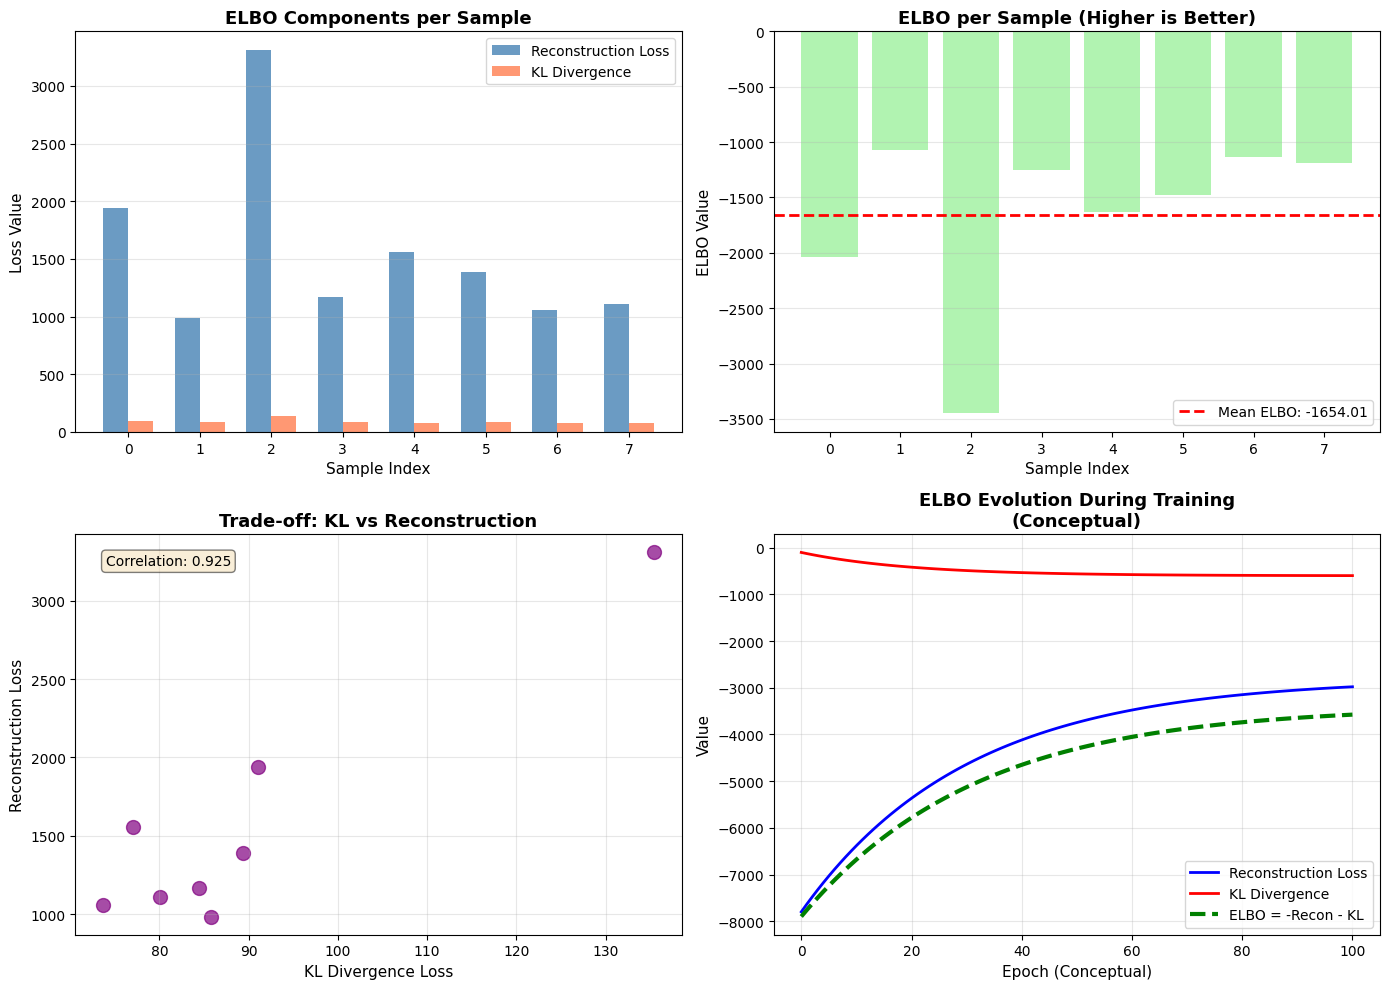

   Mean Reconstruction Loss: 1564.39
   Mean KL Divergence: 89.62
   Mean ELBO: -1654.01
   ELBO Range: [-3443.66, -1070.85]
   ELBO = -Reconstruction_Loss - KL_Divergence
   Higher ELBO = Better model (lower reconstruction + controlled KL)


In [50]:
vae_model.eval()

with torch.no_grad():
    sample_batch, _ = next(iter(validation_data_loader))
    sample_batch = sample_batch[:8].to(device)

    reconstructed, mu, logvar = vae_model(sample_batch)

    recon_losses = []
    kl_losses = []
    elbo_values = []

    for i in range(sample_batch.size(0)):
        recon_loss = nn.functional.mse_loss(
            reconstructed[i:i+1], sample_batch[i:i+1], reduction='sum'
        ).item()

        kl_loss = -0.5 * torch.sum(
            1 + logvar[i] - mu[i].pow(2) - logvar[i].exp()
        ).item()

        elbo = -recon_loss - kl_loss

        recon_losses.append(recon_loss)
        kl_losses.append(kl_loss)
        elbo_values.append(elbo)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

x_pos = np.arange(len(recon_losses))
width = 0.35
axes[0, 0].bar(x_pos - width/2, recon_losses, width, label='Reconstruction Loss', alpha=0.8, color='steelblue')
axes[0, 0].bar(x_pos + width/2, kl_losses, width, label='KL Divergence', alpha=0.8, color='coral')
axes[0, 0].set_xlabel('Sample Index', fontsize=11)
axes[0, 0].set_ylabel('Loss Value', fontsize=11)
axes[0, 0].set_title('ELBO Components per Sample', fontsize=13, fontweight='bold')
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3, axis='y')

axes[0, 1].bar(x_pos, elbo_values, alpha=0.7, color='lightgreen')
axes[0, 1].axhline(np.mean(elbo_values), color='red', linestyle='--', linewidth=2,
                   label=f'Mean ELBO: {np.mean(elbo_values):.2f}')
axes[0, 1].set_xlabel('Sample Index', fontsize=11)
axes[0, 1].set_ylabel('ELBO Value', fontsize=11)
axes[0, 1].set_title('ELBO per Sample (Higher is Better)', fontsize=13, fontweight='bold')
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3, axis='y')

axes[1, 0].scatter(kl_losses, recon_losses, alpha=0.7, s=100, color='purple')
axes[1, 0].set_xlabel('KL Divergence Loss', fontsize=11)
axes[1, 0].set_ylabel('Reconstruction Loss', fontsize=11)
axes[1, 0].set_title('Trade-off: KL vs Reconstruction', fontsize=13, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

correlation = np.corrcoef(kl_losses, recon_losses)[0, 1]
axes[1, 0].text(0.05, 0.95, f'Correlation: {correlation:.3f}',
                transform=axes[1, 0].transAxes, fontsize=10,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

epochs_example = np.linspace(0, 100, 100)
recon_sim = 5000 * np.exp(-epochs_example / 30) + 2800
kl_sim = 500 * (1 - np.exp(-epochs_example / 20)) + 100
elbo_sim = -recon_sim - kl_sim

axes[1, 1].plot(epochs_example, -recon_sim, label='Reconstruction Loss', linewidth=2, color='blue')
axes[1, 1].plot(epochs_example, -kl_sim, label='KL Divergence', linewidth=2, color='red')
axes[1, 1].plot(epochs_example, elbo_sim, label='ELBO = -Recon - KL', linewidth=3, color='green', linestyle='--')
axes[1, 1].set_xlabel('Epoch (Conceptual)', fontsize=11)
axes[1, 1].set_ylabel('Value', fontsize=11)
axes[1, 1].set_title('ELBO Evolution During Training\n(Conceptual)', fontsize=13, fontweight='bold')
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"   Mean Reconstruction Loss: {np.mean(recon_losses):.2f}")
print(f"   Mean KL Divergence: {np.mean(kl_losses):.2f}")
print(f"   Mean ELBO: {np.mean(elbo_values):.2f}")
print(f"   ELBO Range: [{np.min(elbo_values):.2f}, {np.max(elbo_values):.2f}]")
print(f"   ELBO = -Reconstruction_Loss - KL_Divergence")
print(f"   Higher ELBO = Better model (lower reconstruction + controlled KL)")


# Section 6.2: Reparameterization Trick Demonstration

## Objective
Demonstrate how the reparameterization trick works, showing the transformation from deterministic parameters (μ, σ) to stochastic latent variables (z).

## Key Concept

**Without reparameterization**: Cannot backpropagate through random sampling
```
z ~ N(μ, σ²)  ❌ No gradients!
```

**With reparameterization**: Separate randomness from parameters
```
ε ~ N(0, 1)        (independent random sample)
z = μ + σ ⊙ ε     ✓ Gradients flow through μ and σ
```

## Why This Matters
- Enables gradient-based optimization of stochastic variables
- Allows end-to-end training of the VAE
- Fundamental to making VAEs trainable


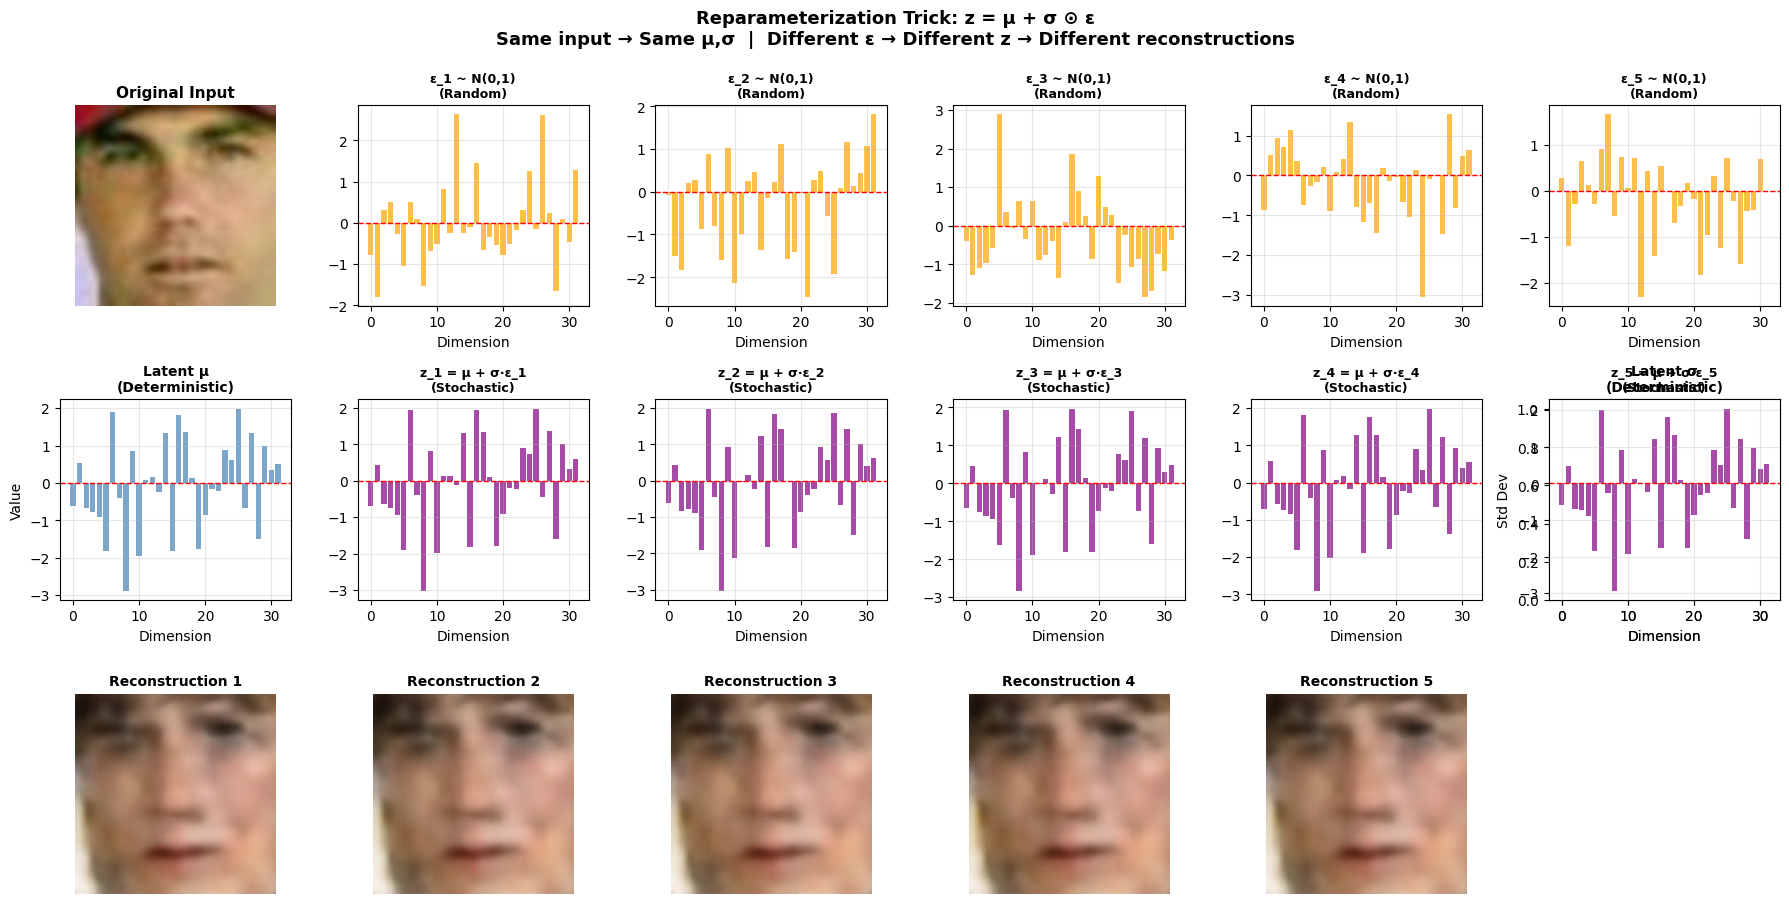


🔀 Reparameterization Demonstration:
   Same input → Same μ, σ (deterministic)
   Different ε samples → Different z (stochastic)
   Different z → Different reconstructions

📊 Statistics across 5 samples:
   Mean z across samples: -0.0917 (target: -0.0756)
   Std z across samples: 1.2280
   ✓ Shows stochastic sampling variability


In [22]:
def visualize_reparameterization(model, sample_image, device, num_samples=5):
    """
    Visualize the reparameterization trick by showing multiple samples
    from the same input using different random epsilons.
    """
    model.eval()

    with torch.no_grad():
        sample_image = sample_image.unsqueeze(0).to(device)

        encoded = model.encoder_net(sample_image)
        mu = model.mean_fc(encoded)
        logvar = model.logvar_fc(encoded)
        std = torch.exp(0.5 * logvar)

        reconstructions = []
        latent_samples = []
        epsilons = []

        for i in range(num_samples):
            epsilon = torch.randn_like(std)
            epsilons.append(epsilon.cpu())
            z = mu + std * epsilon
            latent_samples.append(z.cpu())

            decoder_input = model.decoder_input_fc(z)
            decoder_input = nn.functional.leaky_relu(decoder_input, negative_slope=0.2)
            reconstructed = model.decoder_net(decoder_input)
            reconstructions.append(reconstructed.cpu())

    fig = plt.figure(figsize=(18, 12))

    ax = fig.add_subplot(4, num_samples + 1, 1)
    ax.imshow((sample_image[0].cpu() * 0.5 + 0.5).permute(1, 2, 0).clamp(0, 1))
    ax.set_title('Original Input', fontsize=11, fontweight='bold')
    ax.axis('off')

    ax_mu = fig.add_subplot(4, num_samples + 1, num_samples + 2)
    mu_np = mu[0].cpu().numpy()
    ax_mu.bar(range(len(mu_np)), mu_np, alpha=0.7, color='steelblue')
    ax_mu.axhline(0, color='red', linestyle='--', linewidth=1)
    ax_mu.set_title(f'Latent μ\n(Deterministic)', fontsize=10, fontweight='bold')
    ax_mu.set_xlabel('Dimension')
    ax_mu.set_ylabel('Value')
    ax_mu.grid(True, alpha=0.3)

    ax_std = fig.add_subplot(4, num_samples + 1, 2 * (num_samples + 1))
    std_np = std[0].cpu().numpy()
    ax_std.bar(range(len(std_np)), std_np, alpha=0.7, color='lightgreen')
    ax_std.axhline(1, color='red', linestyle='--', linewidth=1)
    ax_std.set_title(f'Latent σ\n(Deterministic)', fontsize=10, fontweight='bold')
    ax_std.set_xlabel('Dimension')
    ax_std.set_ylabel('Std Dev')
    ax_std.grid(True, alpha=0.3)

    for i in range(num_samples):
        ax_eps = fig.add_subplot(4, num_samples + 1, i + 2)
        eps_np = epsilons[i][0].numpy()
        ax_eps.bar(range(len(eps_np)), eps_np, alpha=0.7, color='orange')
        ax_eps.axhline(0, color='red', linestyle='--', linewidth=1)
        ax_eps.set_title(f'ε_{i+1} ~ N(0,1)\n(Random)', fontsize=9, fontweight='bold')
        ax_eps.set_xlabel('Dimension')
        ax_eps.grid(True, alpha=0.3)

        ax_z = fig.add_subplot(4, num_samples + 1, num_samples + 3 + i)
        z_np = latent_samples[i][0].numpy()
        ax_z.bar(range(len(z_np)), z_np, alpha=0.7, color='purple')
        ax_z.axhline(0, color='red', linestyle='--', linewidth=1)
        ax_z.set_title(f'z_{i+1} = μ + σ·ε_{i+1}\n(Stochastic)', fontsize=9, fontweight='bold')
        ax_z.set_xlabel('Dimension')
        ax_z.grid(True, alpha=0.3)

        ax_recon = fig.add_subplot(4, num_samples + 1, 2 * (num_samples + 1) + 1 + i)
        ax_recon.imshow((reconstructions[i][0] * 0.5 + 0.5).permute(1, 2, 0).clamp(0, 1))
        ax_recon.set_title(f'Reconstruction {i+1}', fontsize=10, fontweight='bold')
        ax_recon.axis('off')

    plt.suptitle('Reparameterization Trick: z = μ + σ ⊙ ε\n' +
                 'Same input → Same μ,σ  |  Different ε → Different z → Different reconstructions',
                 fontsize=13, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()

    print(f"   Same input → Same μ, σ (deterministic)")
    print(f"   Different ε samples → Different z (stochastic)")
    print(f"   Different z → Different reconstructions")
    print(f"\n Statistics across {num_samples} samples:")
    all_z = torch.stack(latent_samples)
    print(f"   Mean z across samples: {all_z.mean().item():.4f} (target: {mu.mean().item():.4f})")
    print(f"   Std z across samples: {all_z.std().item():.4f}")
    print(f"   ✓ Shows stochastic sampling variability")

sample_img, _ = next(iter(validation_data_loader))
sample_img = sample_img[0]

visualize_reparameterization(vae_model, sample_img, device, num_samples=5)


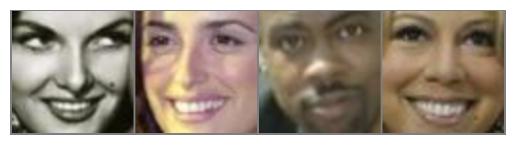

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import torchvision

def display_images(image_tensor):
    undo_normalization_factor = 0.5
    image_tensor = image_tensor * undo_normalization_factor + undo_normalization_factor
    np_image_array = image_tensor.numpy()
    plt.imshow(np.transpose(np_image_array, (1, 2, 0)))
    plt.axis('off')
    plt.show()

data_iterator = iter(training_data_loader)
sample_images, sample_labels = next(data_iterator)

num_images_to_show = 4
image_grid = torchvision.utils.make_grid(sample_images[:num_images_to_show])

display_images(image_grid)


# Section 5: Model Architecture and Definition

## 5.1 Objective

This section defines the Variational Autoencoder (VAE) model architecture. The VAE consists of an encoder that compresses images into a latent space with mean and log-variance parameters, a reparameterization trick for sampling, and a decoder that reconstructs images from latent vectors.

## 5.2 Model Architecture

### 5.2.1 Encoder Network
- **4 Convolutional layers**: Reduce spatial dimensions from 128×128 to 8×8
- **BatchNorm and Dropout**: For stability and preventing overfitting
- **2 Fully Connected layers**: For generating mean and log variance of latent space

### 5.2.2 Decoder Network
- **1 Fully Connected layer**: Transform latent vector to appropriate shape
- **4 Transposed Convolutional layers**: Increase dimensions from 8×8 to 128×128
- **Final activation function**: Tanh to limit output to range [-1, 1]

### 5.2.3 Key Parameters
- **hidden_dim**: 4096 (hidden dimension)
- **latent_dim**: 32 (latent space dimension)

## 5.3 Reparameterization Trick

To enable backpropagation through stochastic sampling:
$$z = \mu + \sigma \odot \epsilon$$
where $\epsilon \sim \mathcal{N}(0, 1)$ and $\sigma = \exp(0.5 \times \logvar)$

In [17]:
import torch
from torch import nn


class VariationalAutoencoder(nn.Module):
    def __init__(self, hidden_dim=4096, latent_dim=32):
        super(VariationalAutoencoder, self).__init__()

        self.encoder_net = nn.Sequential(
            nn.Conv2d(
                in_channels=3, out_channels=32, kernel_size=4, stride=2, padding=1
            ),
            nn.LeakyReLU(0.2),
            nn.Conv2d(
                in_channels=32, out_channels=64, kernel_size=4, stride=2, padding=1
            ),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.Conv2d(
                in_channels=64, out_channels=128, kernel_size=4, stride=2, padding=1
            ),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Conv2d(
                in_channels=128, out_channels=256, kernel_size=4, stride=2, padding=1
            ),
            nn.LeakyReLU(0.2),
            nn.Flatten(),
            nn.Linear(in_features=256 * 8 * 8, out_features=hidden_dim),
            nn.LeakyReLU(0.2),
        )

        self.mean_fc = nn.Linear(hidden_dim, latent_dim)
        self.logvar_fc = nn.Linear(hidden_dim, latent_dim)

        self.decoder_input_fc = nn.Linear(latent_dim, hidden_dim)
        self.decoder_net = nn.Sequential(
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, 256 * 8 * 8),
            nn.LeakyReLU(0.2),
            nn.Unflatten(dim=1, unflattened_size=(256, 8, 8)),
            nn.ConvTranspose2d(
                in_channels=256, out_channels=128, kernel_size=4, stride=2, padding=1
            ),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.ConvTranspose2d(
                in_channels=128, out_channels=64, kernel_size=4, stride=2, padding=1
            ),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.ConvTranspose2d(
                in_channels=64, out_channels=32, kernel_size=4, stride=2, padding=1
            ),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(
                in_channels=32, out_channels=3, kernel_size=4, stride=2, padding=1
            ),
            nn.Tanh(),
        )

    def reparameterize(self, mean, logvar):
        logvar = torch.clamp(logvar, min=-10, max=10)
        std_dev = torch.exp(0.5 * logvar)
        epsilon = torch.randn_like(std_dev)
        return mean + epsilon * std_dev

    def forward(self, input_data):
        encoded_features = self.encoder_net(input_data)
        mean = self.mean_fc(encoded_features)
        logvar = self.logvar_fc(encoded_features)
        latent_vector = self.reparameterize(mean, logvar)

        decoder_input = self.decoder_input_fc(latent_vector)
        decoder_input = nn.functional.leaky_relu(decoder_input, negative_slope=0.2)
        reconstructed_output = self.decoder_net(decoder_input)

        return reconstructed_output, mean, logvar

# Section 6: Loss Function

## 6.1 Objective

This section defines the loss function for training the VAE, which includes a reconstruction loss (MSE between original and reconstructed images) and a KL divergence loss to ensure the latent distribution matches the prior.

## 6.2 Loss Function Components

### 6.2.1 Reconstruction Loss
- **Type**: Mean Squared Error (MSE)
- **Formula**: $\mathcal{L}_{\text{recon}} = \text{MSE}(x, \hat{x}) = \sum (x - \hat{x})^2$
- **Purpose**: Encourages the model to accurately reconstruct input images

### 6.2.2 KL Divergence Loss
- **Formula**: $\mathcal{L}_{\text{KL}} = -0.5 \times \sum(1 + \logvar - \mu^2 - \exp(\logvar))$
- **Purpose**: Regularizes latent space to follow standard normal distribution
- **Importance**: Ensures smooth interpolation in latent space

### 6.2.3 Total Loss
$$\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{recon}} + \mathcal{L}_{\text{KL}}$$

## 6.3 Balance Between Components

- High Reconstruction Loss → More accurate reconstruction but irregular latent space
- High KL Loss → More regular latent space but less accurate reconstruction
- Proper balance is essential for optimal performance

In [14]:
def vae_loss_function(reconstructed_x, original_x, latent_mean, latent_logvar):
    reconstruction_loss = nn.functional.mse_loss(reconstructed_x, original_x, reduction='sum')
    kl_divergence_loss = -0.5 * torch.sum(1 + latent_logvar - latent_mean.pow(2) - latent_logvar.exp())
    total_loss = reconstruction_loss + kl_divergence_loss
    return total_loss, reconstruction_loss, kl_divergence_loss


# Section 7: Training Configuration

## 7.1 Objective

This section sets up training parameters, initializes the VAE model and Adam optimizer, and executes the training loop. It tracks training and validation losses over epochs to monitor convergence.

## 7.2 Training Parameters

| Parameter | Value | Description |
|-----------|-------|-------------|
| **Epochs** | 1000 | Number of complete training epochs |
| **Learning Rate** | 0.0005 | Learning rate for Adam optimizer |
| **Optimizer** | Adam | Optimization algorithm |
| **Latent Dimension** | 32 | Latent space dimension |

## 7.3 Loss Tracking

During training, the following are tracked:
- **Training Total Loss**: Sum of reconstruction and KL loss on training data
- **Validation Loss**: Loss on validation data
- **Reconstruction Loss**: Separate reconstruction loss
- **KL Divergence Loss**: Separate KL divergence loss

## 7.4 Convergence Analysis

- Consistent decrease in losses → Proper convergence
- Large gap between training and validation loss → Potential overfitting
- High fluctuations → Need to adjust learning rate or model structure

In [ ]:
num_epochs = 1000
initial_learning_rate = 0.0005

vae_model = VariationalAutoencoder(32).to(device)
optimizer = torch.optim.Adam(vae_model.parameters(), lr=initial_learning_rate)

train_total_losses = []
validation_losses = []
train_reconstruction_losses = []
train_kl_divergence_losses = []



In [19]:
for epoch in range(num_epochs):
    vae_model.train()
    epoch_train_loss = 0
    epoch_reconstruction_loss = 0
    epoch_kl_divergence_loss = 0

    for batch_index, (batch_data, _) in enumerate(training_data_loader):
        batch_data = batch_data.to(device)
        optimizer.zero_grad()

        reconstructed_batch, latent_mu, latent_logvar = vae_model(batch_data)
        total_loss, reconstruction_loss, kl_divergence_loss = vae_loss_function(
            reconstructed_batch, batch_data, latent_mu, latent_logvar
        )

        total_loss.backward()
        optimizer.step()

        epoch_train_loss += total_loss.item()
        epoch_reconstruction_loss += reconstruction_loss.item()
        epoch_kl_divergence_loss += kl_divergence_loss.item()

    train_total_losses.append(epoch_train_loss / len(training_data_loader.dataset))
    train_reconstruction_losses.append(
        epoch_reconstruction_loss / len(training_data_loader.dataset)
    )
    train_kl_divergence_losses.append(
        epoch_kl_divergence_loss / len(training_data_loader.dataset)
    )

    vae_model.eval()
    epoch_validation_loss = 0

    with torch.no_grad():
        for val_data, _ in validation_data_loader:
            val_data = val_data.to(device)
            recon_val_batch, val_mu, val_logvar = vae_model(val_data)
            val_loss, _, _ = vae_loss_function(
                recon_val_batch, val_data, val_mu, val_logvar
            )
            epoch_validation_loss += val_loss.item()

    validation_losses.append(
        epoch_validation_loss / len(validation_data_loader.dataset)
    )

    print(
        f"Epoch {epoch}, Train Loss: {train_total_losses[-1]:.4f}, Validation Loss: {validation_losses[-1]:.4f}"
    )

Epoch 0, Train Loss: 5723.1395, Validation Loss: 4038.5870
Epoch 1, Train Loss: 3878.8018, Validation Loss: 3812.4055
Epoch 2, Train Loss: 3282.5172, Validation Loss: 3005.4423
Epoch 3, Train Loss: 2916.3946, Validation Loss: 2712.5822
Epoch 4, Train Loss: 2694.7396, Validation Loss: 2537.8280
Epoch 5, Train Loss: 2588.8474, Validation Loss: 2476.2488
Epoch 6, Train Loss: 2465.8181, Validation Loss: 2292.9311
Epoch 7, Train Loss: 2340.3674, Validation Loss: 2244.0549
Epoch 8, Train Loss: 2300.5395, Validation Loss: 2197.6335
Epoch 9, Train Loss: 2215.8150, Validation Loss: 2180.7862
Epoch 10, Train Loss: 2132.6602, Validation Loss: 2096.7744
Epoch 11, Train Loss: 2060.8066, Validation Loss: 2093.5588
Epoch 12, Train Loss: 2070.1679, Validation Loss: 2149.6141
Epoch 13, Train Loss: 2007.3738, Validation Loss: 2057.8392
Epoch 14, Train Loss: 1986.3513, Validation Loss: 2031.6026
Epoch 15, Train Loss: 1901.9831, Validation Loss: 1940.6102
Epoch 16, Train Loss: 1865.3353, Validation Loss: 

KeyboardInterrupt: 

# Section 8: Evaluation - Image Reconstruction

## 8.1 Objective

This section switches the model to evaluation mode and reconstructs images from the validation dataset. It displays original and reconstructed images side by side in a grid, demonstrating the VAE's ability to compress and decompress image data.

## 8.2 Evaluation Criteria

### 8.2.1 Reconstruction Quality
- **Preservation of main features**: Face and main structure should be preserved
- **Detail quality**: Important details should be discernible
- **Smoothing**: Reconstructed images may be smoother due to latent space regularization

### 8.2.2 Results Analysis
1. **Successful reconstruction**: Reconstructed images resemble originals
2. **Acceptable quality**: Main features are recognizable
3. **Needs improvement**: Poor reconstruction or loss of important features

## 8.3 Interpretation

- Accurate reconstructions indicate effective latent space learning
- Excessive smoothing may indicate strong KL divergence influence
- Loss of fine details may be due to low latent space dimensions

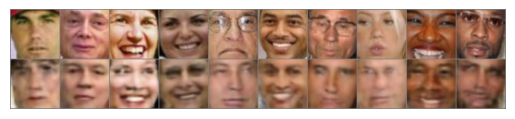

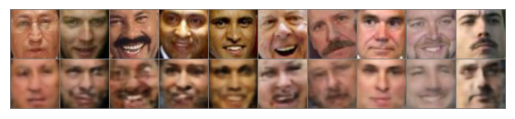

In [25]:
vae_model.eval()
with torch.no_grad():
    validation_iterator = iter(validation_data_loader)
    sample_data, _ = next(validation_iterator)
    sample_data = sample_data.to(device)

    reconstructed_batch, _, _ = vae_model(sample_data)

    num_images_display = 10

    image_comparison = torch.cat(
        [sample_data[:num_images_display], reconstructed_batch[:num_images_display]]
    )
    image_comparison = image_comparison.cpu()

    grid_image = torchvision.utils.make_grid(image_comparison, nrow=num_images_display)
    display_images(grid_image)

    sample_data, _ = next(validation_iterator)
    sample_data = sample_data.to(device)
    reconstructed_batch, _, _ = vae_model(sample_data)

    num_images_display = 10

    image_comparison = torch.cat(
        [sample_data[:num_images_display], reconstructed_batch[:num_images_display]]
    )
    image_comparison = image_comparison.cpu()

    grid_image = torchvision.utils.make_grid(image_comparison, nrow=num_images_display)
    display_images(grid_image)



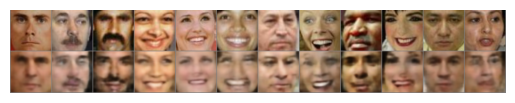

In [26]:
with torch.no_grad():
    sample_data, _ = next(validation_iterator)
    sample_data = sample_data.to(device)

    reconstructed_batch, _, _ = vae_model(sample_data)

    num_images_display = 12

    image_comparison = torch.cat(
        [sample_data[:num_images_display], reconstructed_batch[:num_images_display]]
    )
    image_comparison = image_comparison.cpu()

    grid_image = torchvision.utils.make_grid(image_comparison, nrow=num_images_display)
    display_images(grid_image)

---

# Part IV: Training

This section covers the training process, monitoring, and loss analysis.

---


# Section 9: Training Loss Visualization

## 9.1 Objective

This visualization plots the reconstruction loss (measuring how well the model reconstructs inputs) and KL divergence loss (ensuring the latent space follows the prior distribution) over epochs. The plot shows convergence and the trade-off between the two loss components.

## 9.2 Loss Chart Analysis

### 9.2.1 Expected Patterns

1. **Successful convergence**:
   - Consistent decrease in both losses over time
   - Reaching a stable level

2. **Proper balance**:
   - Reconstruction Loss at reasonable level (not too high)
   - KL Loss at moderate level (effective regularization but not excessive)

3. **Potential issues**:
   - Reconstruction Loss too high → Model has difficulty reconstructing
   - KL Loss too low (close to zero) → Latent space not regularized
   - Reconstruction Loss too low + KL Loss high → Overfitting to training data

## 9.3 Important Notes

- **Trade-off**: Decreasing Reconstruction Loss usually accompanies increasing KL Loss
- **Continuous monitoring**: Tracking both losses is essential for optimal balance
- **Comparison with Validation**: Large difference with validation loss may indicate overfitting

# Section 9.2: Training vs Validation Loss Comparison

## Objective
This visualization compares training and validation losses side by side to monitor model performance, detect overfitting, and track convergence patterns.

## Key Insights
- **Convergence Monitoring**: Both losses should decrease and converge together
- **Overfitting Detection**: Large gap between training and validation loss indicates overfitting
- **Generalization Assessment**: Close tracking indicates good generalization


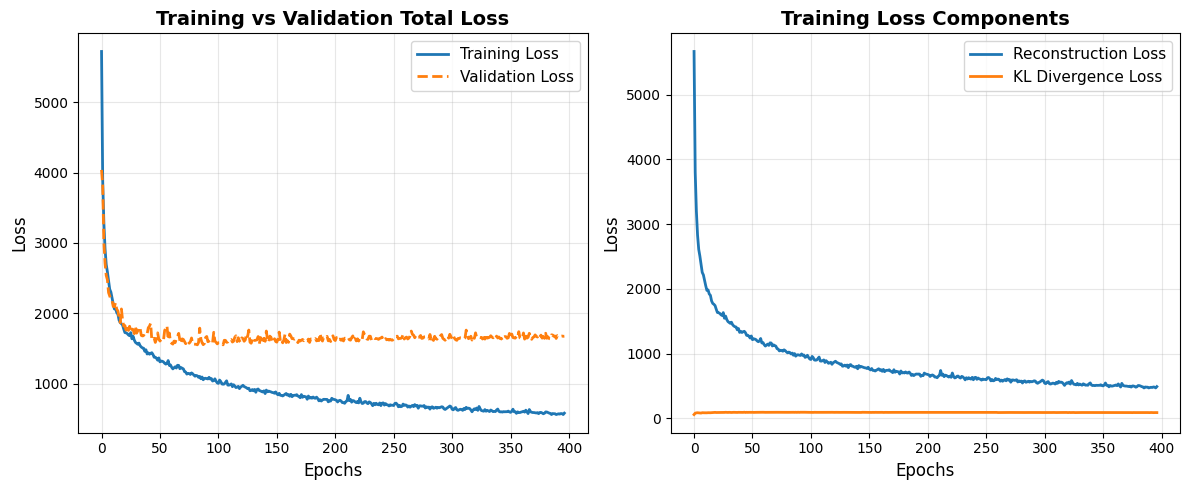


📊 Loss Statistics:
   Final Training Loss: 578.6939
   Final Validation Loss: 1673.3289
   Train-Val Gap: 65.42%
   ✗ Potential overfitting detected


In [27]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_total_losses, label="Training Loss", linewidth=2)
plt.plot(validation_losses, label="Validation Loss", linewidth=2, linestyle='--')
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.title("Training vs Validation Total Loss", fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(train_reconstruction_losses, label="Reconstruction Loss", linewidth=2)
plt.plot(train_kl_divergence_losses, label="KL Divergence Loss", linewidth=2)
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.title("Training Loss Components", fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

final_train_loss = train_total_losses[-1]
final_val_loss = validation_losses[-1]
gap_percentage = abs((final_train_loss - final_val_loss) / final_val_loss) * 100

print(f"\n📊 Loss Statistics:")
print(f"   Final Training Loss: {final_train_loss:.4f}")
print(f"   Final Validation Loss: {final_val_loss:.4f}")
print(f"   Train-Val Gap: {gap_percentage:.2f}%")
if gap_percentage < 5:
    print(f"   ✓ Good generalization (gap < 5%)")
elif gap_percentage < 15:
    print(f"   ⚠ Moderate overfitting risk")
else:
    print(f"   ✗ Potential overfitting detected")


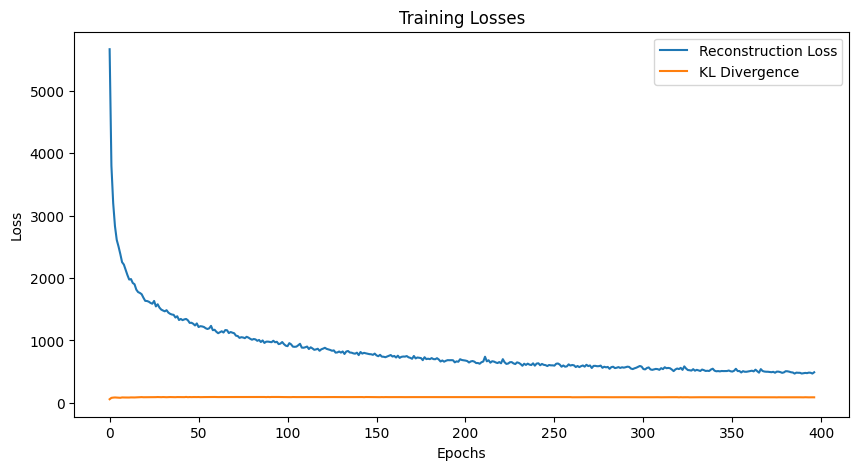

In [28]:
plot_width, plot_height = 10, 5
plot_title = "Training Losses"
x_label = "Epochs"
y_label = "Loss"

plt.figure(figsize=(plot_width, plot_height))
plt.title(plot_title)
plt.plot(train_reconstruction_losses, label="Reconstruction Loss")
plt.plot(train_kl_divergence_losses, label="KL Divergence")
plt.xlabel(x_label)
plt.ylabel(y_label)
plt.legend()
plt.show()

---

# Part V: Evaluation & Analysis

This section evaluates model performance through reconstruction, generation, and latent space analysis.

---


In [29]:
from torchsummary import summary

try:
    print("=" * 80)
    print("VAE MODEL ARCHITECTURE SUMMARY")
    print("=" * 80)

    total_params = sum(p.numel() for p in vae_model.parameters())
    trainable_params = sum(p.numel() for p in vae_model.parameters() if p.requires_grad)

    print(f"\n📐 Model Parameters:")
    print(f"   Total Parameters: {total_params:,}")
    print(f"   Trainable Parameters: {trainable_params:,}")
    print(f"   Model Size: ~{total_params * 4 / (1024**2):.2f} MB (float32)")

    print(f"\n🏗️ Encoder Architecture:")
    encoder_params = sum(p.numel() for p in vae_model.encoder_net.parameters())
    mu_params = sum(p.numel() for p in vae_model.mean_fc.parameters())
    logvar_params = sum(p.numel() for p in vae_model.logvar_fc.parameters())
    print(f"   Encoder Conv Layers: {encoder_params:,} params")
    print(f"   Mean FC Layer (μ): {mu_params:,} params")
    print(f"   LogVar FC Layer (log σ²): {logvar_params:,} params")

    print(f"\n🎨 Decoder Architecture:")
    decoder_params = sum(p.numel() for p in vae_model.decoder_net.parameters())
    decoder_fc_params = sum(p.numel() for p in vae_model.decoder_input_fc.parameters())
    print(f"   Decoder FC Input: {decoder_fc_params:,} params")
    print(f"   Decoder ConvTranspose Layers: {decoder_params:,} params")

    print(f"\n📊 Latent Space:")
    sample_input = torch.randn(1, 3, 128, 128).to(device)
    with torch.no_grad():
        encoded = vae_model.encoder_net(sample_input)
        mu = vae_model.mean_fc(encoded)
        logvar = vae_model.logvar_fc(encoded)
        z = vae_model.reparameterize(mu, logvar)

    print(f"   Input Shape: {sample_input.shape}")
    print(f"   Latent μ Shape: {mu.shape}")
    print(f"   Latent log σ² Shape: {logvar.shape}")
    print(f"   Latent z Shape: {z.shape}")
    print(f"   Compression Ratio: {sample_input.numel() / z.numel():.1f}:1")

    print("\n" + "=" * 80)
except Exception as e:
    print(f"Could not generate detailed summary: {e}")
    print("Model structure:")
    print(vae_model)


VAE MODEL ARCHITECTURE SUMMARY

📐 Model Parameters:
   Total Parameters: 2,448,963
   Trainable Parameters: 2,448,963
   Model Size: ~9.34 MB (float32)

🏗️ Encoder Architecture:
   Encoder Conv Layers: 1,214,848 params
   Mean FC Layer (μ): 1,056 params
   LogVar FC Layer (log σ²): 1,056 params

🎨 Decoder Architecture:
   Decoder FC Input: 1,056 params
   Decoder ConvTranspose Layers: 1,230,947 params

📊 Latent Space:
   Input Shape: torch.Size([1, 3, 128, 128])
   Latent μ Shape: torch.Size([1, 32])
   Latent log σ² Shape: torch.Size([1, 32])
   Latent z Shape: torch.Size([1, 32])
   Compression Ratio: 1536.0:1



# Section 10: Image Generation

## 10.1 Objective

This section demonstrates the generative aspect of the VAE by sampling random vectors from the latent space prior and generating corresponding images through the decoder. The grid shows diverse samples produced by the model.

## 10.2 Generation Method

1. **Sampling from Prior**: Latent vectors are sampled from standard normal distribution $\mathcal{N}(0, I)$
2. **Passing through Decoder**: Sampled vectors are passed through the decoder
3. **Image Generation**: Corresponding images are generated

## 10.3 Generation Quality Analysis

### 10.3.1 Evaluation Criteria

**Good quality**:
- Realistic and recognizable images
- Appropriate diversity between samples
- Absence of blurry or irregular samples

**Needs improvement**:
- Blurry or noisy images
- Low diversity (mode collapse)
- Generating illogical images

### 10.3.2 Results Interpretation

- **Successful generation**: Indicates good data distribution learning in latent space
- **Low quality**: May need more training or hyperparameter tuning
- **Low diversity**: May indicate mode collapse or low latent space dimensions

# Section 12.2: PCA vs t-SNE Comparison

## Objective
Compare both PCA and t-SNE dimensionality reduction techniques to visualize latent space structure. PCA preserves global structure while t-SNE emphasizes local neighborhoods.

## Comparison Insights
- **PCA**: Linear transformation, preserves global distances, faster
- **t-SNE**: Non-linear, emphasizes local structure, better for clustering visualization


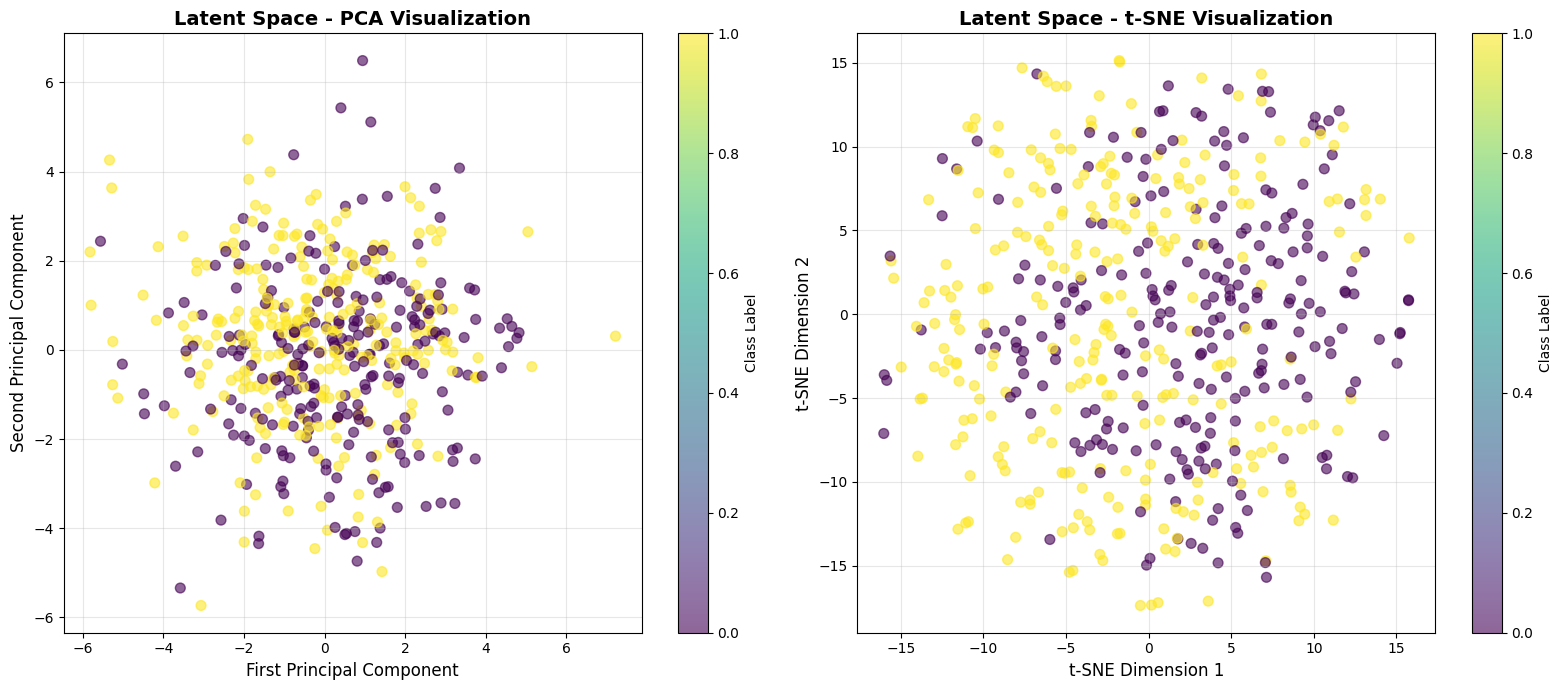


📊 PCA Analysis:
   Variance Explained by PC1: 10.24%
   Variance Explained by PC2: 8.39%
   Total Variance Explained: 18.63%


In [30]:
def extract_latent_vectors(model, data_loader, num_samples=500):
    model.eval()
    latent_vectors = []
    labels = []

    with torch.no_grad():
        for i, (images, target) in enumerate(data_loader):
            if i * images.size(0) >= num_samples:
                break
            images = images.to(device)
            _, mean, logvar = model(images)
            latent_z = model.reparameterize(mean, logvar)
            latent_vectors.append(latent_z.cpu())
            labels.extend(target.cpu().numpy())

    return torch.cat(latent_vectors).numpy(), np.array(labels)

latent_vectors, labels = extract_latent_vectors(vae_model, training_data_loader, num_samples=500)

pca = PCA(n_components=2)
latent_pca = pca.fit_transform(latent_vectors)

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
latent_tsne = tsne.fit_transform(latent_vectors)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

scatter1 = axes[0].scatter(latent_pca[:, 0], latent_pca[:, 1], c=labels,
                           cmap='viridis', alpha=0.6, s=50)
axes[0].set_xlabel('First Principal Component', fontsize=12)
axes[0].set_ylabel('Second Principal Component', fontsize=12)
axes[0].set_title('Latent Space - PCA Visualization', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0], label='Class Label')

scatter2 = axes[1].scatter(latent_tsne[:, 0], latent_tsne[:, 1], c=labels,
                            cmap='viridis', alpha=0.6, s=50)
axes[1].set_xlabel('t-SNE Dimension 1', fontsize=12)
axes[1].set_ylabel('t-SNE Dimension 2', fontsize=12)
axes[1].set_title('Latent Space - t-SNE Visualization', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=axes[1], label='Class Label')

plt.tight_layout()
plt.show()

print(f"\n📊 PCA Analysis:")
print(f"   Variance Explained by PC1: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"   Variance Explained by PC2: {pca.explained_variance_ratio_[1]*100:.2f}%")
print(f"   Total Variance Explained: {sum(pca.explained_variance_ratio_)*100:.2f}%")


# Section 12.3: Latent Space Statistics and Distributions

## Objective
Analyze the statistical properties of latent vectors, including mean and variance distributions across samples and dimensions. This helps understand how the latent space is utilized.

## Key Metrics
- **Latent Mean Distribution**: How means are distributed across samples
- **Latent Variance Distribution**: How variances vary across dimensions
- **KL Divergence per Dimension**: Individual dimension contribution to regularization


---

# Part VI: Advanced Concepts

This section explores advanced VAE concepts including latent space structure, interpolation techniques, and class separation.

---


# Section: Class Separation in Latent Space

## Objective
Analyze how well the VAE separates different classes (smile vs non-smile) in the latent space, demonstrating feature learning and disentanglement.

## Analysis Methods
- Compute class centroids in latent space
- Measure inter-class and intra-class distances
- Visualize class distributions
- Calculate separation metrics


In [31]:
vae_model.eval()

smile_latents = []
nonsmile_latents = []
smile_labels_list = []
nonsmile_labels_list = []

with torch.no_grad():
    for images, labels in training_data_loader:
        images = images.to(device)
        _, mean, logvar = vae_model(images)
        z = vae_model.reparameterize(mean, logvar)

        for i, label in enumerate(labels):
            if label == 0:
                smile_latents.append(z[i].cpu().numpy())
                smile_labels_list.append(0)
            else:
                nonsmile_latents.append(z[i].cpu().numpy())
                nonsmile_labels_list.append(1)


In [32]:

smile_latents = np.array(smile_latents)
nonsmile_latents = np.array(nonsmile_latents)

smile_centroid = smile_latents.mean(axis=0)
nonsmile_centroid = nonsmile_latents.mean(axis=0)

intra_smile = np.mean([np.linalg.norm(s - smile_centroid) for s in smile_latents])
intra_nonsmile = np.mean([np.linalg.norm(n - nonsmile_centroid) for n in nonsmile_latents])
inter_class = np.linalg.norm(smile_centroid - nonsmile_centroid)

separation_ratio = inter_class / ((intra_smile + intra_nonsmile) / 2)


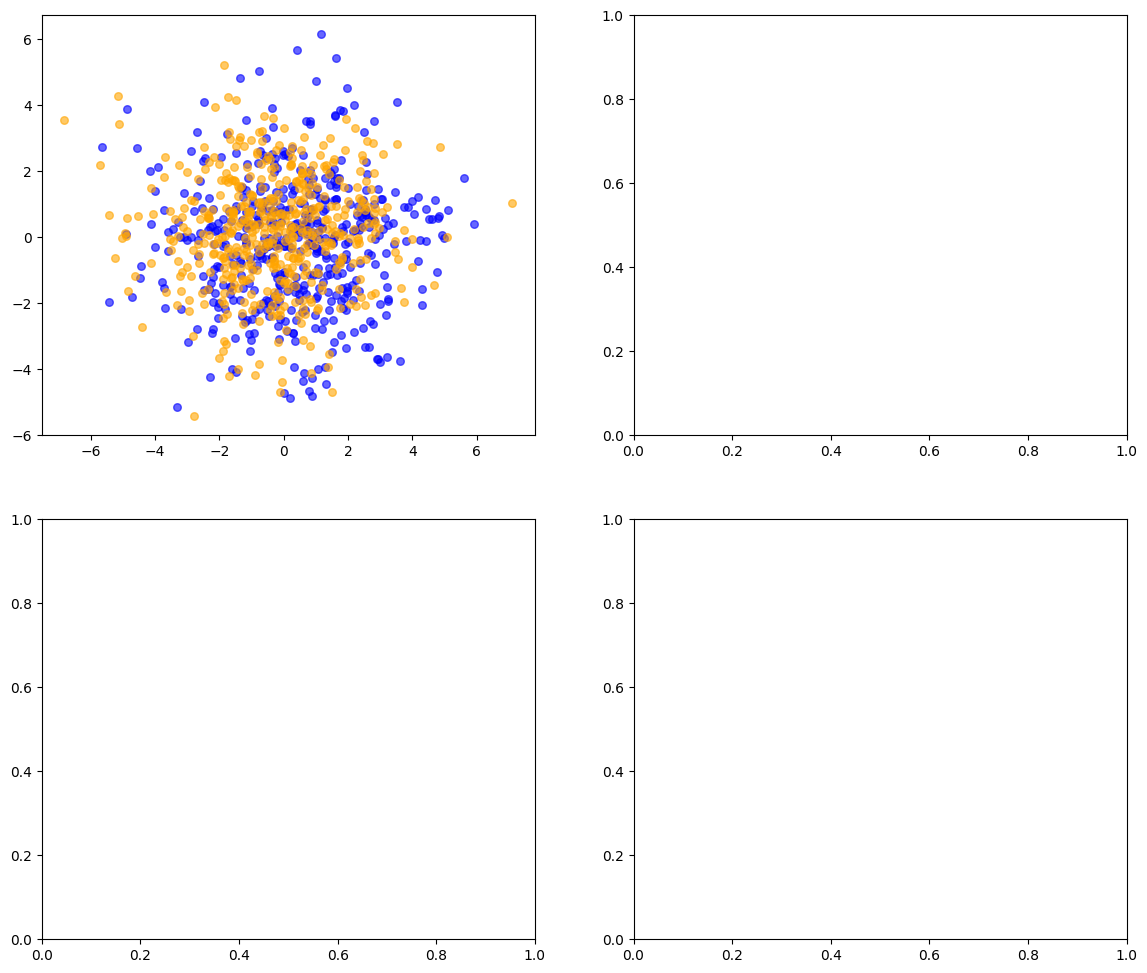

In [33]:

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

all_latents = np.vstack([smile_latents, nonsmile_latents])
all_labels = np.array([0]*len(smile_latents) + [1]*len(nonsmile_latents))

pca_2d = PCA(n_components=2)
latent_pca = pca_2d.fit_transform(all_latents)

scatter1 = axes[0, 0].scatter(latent_pca[all_labels == 0, 0], latent_pca[all_labels == 0, 1],
                              c='blue', alpha=0.6, s=30, label='Smile')
scatter2 = axes[0, 0].scatter(latent_pca[all_labels == 1, 0], latent_pca[all_labels == 1, 1],
                              c='orange', alpha=0.6, s=30, label='Non-Smile')



In [34]:
smile_centroid_pca = pca_2d.transform(smile_centroid.reshape(1, -1))
nonsmile_centroid_pca = pca_2d.transform(nonsmile_centroid.reshape(1, -1))

axes[0, 0].scatter(smile_centroid_pca[0, 0], smile_centroid_pca[0, 1],
                   c='darkblue', s=200, marker='*', label='Smile Centroid', edgecolors='black', linewidths=2)
axes[0, 0].scatter(nonsmile_centroid_pca[0, 0], nonsmile_centroid_pca[0, 1],
                   c='darkorange', s=200, marker='*', label='Non-Smile Centroid', edgecolors='black', linewidths=2)

axes[0, 0].set_xlabel('First Principal Component', fontsize=11)
axes[0, 0].set_ylabel('Second Principal Component', fontsize=11)
axes[0, 0].set_title('Class Separation in Latent Space (PCA)', fontsize=12, fontweight='bold')
axes[0, 0].legend(fontsize=9)
axes[0, 0].grid(True, alpha=0.3)

In [35]:


intra_smile_dists = [np.linalg.norm(s - smile_centroid) for s in smile_latents[:500]]
intra_nonsmile_dists = [np.linalg.norm(n - nonsmile_centroid) for n in nonsmile_latents[:500]]

axes[0, 1].hist(intra_smile_dists, bins=30, alpha=0.7, label=f'Smile (mean={np.mean(intra_smile_dists):.2f})', color='blue')
axes[0, 1].hist(intra_nonsmile_dists, bins=30, alpha=0.7, label=f'Non-Smile (mean={np.mean(intra_nonsmile_dists):.2f})', color='orange')
axes[0, 1].set_xlabel('Distance to Class Centroid', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].set_title('Intra-Class Distance Distribution', fontsize=12, fontweight='bold')
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3, axis='y')

dim_indices = np.arange(min(32, len(smile_centroid)))
axes[1, 0].bar(dim_indices - 0.2, smile_centroid[:len(dim_indices)], width=0.4,
               label='Smile Centroid', alpha=0.7, color='blue')
axes[1, 0].bar(dim_indices + 0.2, nonsmile_centroid[:len(dim_indices)], width=0.4,
               label='Non-Smile Centroid', alpha=0.7, color='orange')
axes[1, 0].set_xlabel('Latent Dimension', fontsize=11)
axes[1, 0].set_ylabel('Centroid Value', fontsize=11)
axes[1, 0].set_title('Class Centroids per Dimension', fontsize=12, fontweight='bold')
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, alpha=0.3, axis='y')


In [36]:

metrics = {
    'Inter-Class Distance': inter_class,
    'Intra-Class (Smile)': intra_smile,
    'Intra-Class (Non-Smile)': intra_nonsmile,
    'Separation Ratio': separation_ratio * 2
}

bars = axes[1, 1].bar(range(len(metrics)), list(metrics.values()),
                      color=['green', 'blue', 'orange', 'red'], alpha=0.7)
axes[1, 1].set_xticks(range(len(metrics)))
axes[1, 1].set_xticklabels(list(metrics.keys()), rotation=45, ha='right', fontsize=10)
axes[1, 1].set_ylabel('Distance/Metric Value', fontsize=11)
axes[1, 1].set_title('Separation Metrics', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')


In [37]:

for i, (bar, (key, val)) in enumerate(zip(bars, metrics.items())):
    if key == 'Separation Ratio':
        axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(metrics.values())*0.02,
                       f'{val/2:.2f}', ha='center', va='bottom', fontsize=9)
    else:
        axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(metrics.values())*0.02,
                       f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


<Figure size 640x480 with 0 Axes>

In [38]:

print(f"      Smile Centroid: mean={smile_centroid.mean():.4f}, std={smile_centroid.std():.4f}")
print(f"      Non-Smile Centroid: mean={nonsmile_centroid.mean():.4f}, std={nonsmile_centroid.std():.4f}")

print(f"      Inter-Class Distance: {inter_class:.4f}")
print(f"      Intra-Class Distance (Smile): {intra_smile:.4f}")
print(f"      Intra-Class Distance (Non-Smile): {intra_nonsmile:.4f}")
print(f"      Separation Ratio: {separation_ratio:.4f} (higher = better separation)")

if separation_ratio > 2:
    print(f"\n   ✓ Excellent class separation!")
elif separation_ratio > 1:
    print(f"\n   ✓ Good class separation")
else:
    print(f"\n   ⚠ Classes could be better separated")

print(f"      Smile: {len(smile_latents)} samples")
print(f"      Non-Smile: {len(nonsmile_latents)} samples")


      Smile Centroid: mean=-0.0784, std=0.4244
      Non-Smile Centroid: mean=-0.0631, std=0.4350
      Inter-Class Distance: 2.1048
      Intra-Class Distance (Smile): 6.0272
      Intra-Class Distance (Non-Smile): 6.1191
      Separation Ratio: 0.3466 (higher = better separation)

   ⚠ Classes could be better separated
      Smile: 473 samples
      Non-Smile: 489 samples


---

# Part VII: Summary & Conclusions

This section provides a comprehensive summary of all VAE features and concepts demonstrated in this project.

---


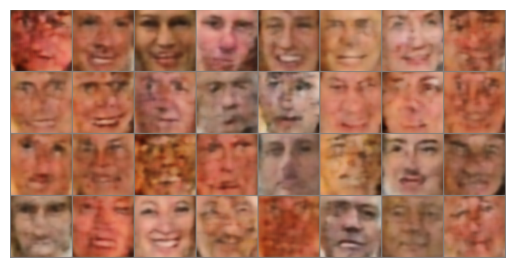

In [40]:
with torch.no_grad():
    latent_dim_size = 32
    num_samples_display = 32
    grid_columns = 8

    random_latent_vectors = torch.randn(batch_volume, latent_dim_size).to(device)

    decoder_input_data = vae_model.decoder_input_fc(random_latent_vectors)
    generated_samples = vae_model.decoder_net(decoder_input_data)
    generated_samples = generated_samples.cpu()

    sample_grid_image = torchvision.utils.make_grid(
        generated_samples[:num_samples_display], nrow=grid_columns
    )
    display_images(sample_grid_image)

# Section 11: Latent Space Exploration

## 11.1 Objective

This section performs latent space interpolation by calculating mean latent vectors for different classes and generating images along a linear path between them. This demonstrates how the VAE captures and manipulates semantic attributes in the latent space.

## 11.2 Method

### 11.2.1 Calculate Mean Latent Vectors
- Compute mean latent vectors for "smile" class
- Compute mean latent vectors for "non_smile" class

### 11.2.2 Define Direction in Latent Space
$$\delta = \mu_{\text{smile}} - \mu_{\text{non\_smile}}$$

This vector represents the difference between the two classes in latent space.

### 11.2.3 Linear Interpolation
For different values of $\alpha$ (e.g., from -3 to 3):
$$z_{\text{interpolated}} = z_{\text{sample}} + \alpha \times \delta$$

## 11.3 Results Analysis

### 11.3.1 Interpolation Expectations

**Successful interpolation**:
- Gradual and smooth transition between two states
- Preservation of overall face structure
- Meaningful change in target attribute (e.g., presence/absence of smile)

**Potential issues**:
- Sudden or irregular changes
- Loss of structure in the middle of the path
- No meaningful change in the target attribute

### 11.3.2 Interpretation

- **Smooth interpolation**: Indicates good latent space structure and feature disentanglement
- **Meaningful transition**: Confirms learning of different class features
- **Role of $\alpha$**: Larger values show more drastic changes

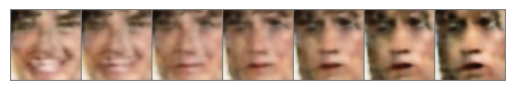

In [42]:
def calculate_latent_means(model, data_loader):
    model.eval()
    latent_means_list, label_collection = [], []
    with torch.no_grad():
        for batch_data, batch_labels in data_loader:
            batch_data = batch_data.to(device)
            encoded_features = model.encoder_net(batch_data)
            latent_mean = model.mean_fc(encoded_features)
            latent_means_list.append(latent_mean.cpu())
            label_collection.append(batch_labels)
    concatenated_latents = torch.cat(latent_means_list)
    concatenated_labels = torch.cat(label_collection)

    mean_smile_latent = concatenated_latents[concatenated_labels == 0].mean(dim=0)
    mean_nonsmile_latent = concatenated_latents[concatenated_labels == 1].mean(dim=0)

    return mean_smile_latent, mean_nonsmile_latent


mean_smile_latent, mean_nonsmile_latent = calculate_latent_means(
    vae_model, training_data_loader
)
latent_direction_vector = (mean_smile_latent - mean_nonsmile_latent).to(device)

validation_data_batch = next(iter(validation_data_loader))
sample_data, sample_labels = validation_data_batch
sample_data = sample_data.to(device)

encoded_sample_data = vae_model.encoder_net(sample_data)
latent_means_batch = vae_model.mean_fc(encoded_sample_data)

selected_sample_index = 0
z_sample = latent_means_batch[selected_sample_index]

alpha_range = np.linspace(-3, 3, 7)
interpolated_images = []

with torch.no_grad():
    for alpha in alpha_range:
        adjusted_latent = z_sample + alpha * latent_direction_vector
        decoder_input_data = vae_model.decoder_input_fc(adjusted_latent)
        decoded_image = vae_model.decoder_net(decoder_input_data.unsqueeze(0))
        interpolated_images.append(decoded_image.cpu())

grid_image = torchvision.utils.make_grid(
    torch.cat(interpolated_images), nrow=len(alpha_range)
)
display_images(grid_image)

# Section 9.4: Reconstruction Error Analysis

## Objective
Analyze reconstruction quality quantitatively by computing per-sample reconstruction errors and visualizing their distribution.

## Key Metrics
- **MSE per Sample**: Individual reconstruction quality for each image
- **Error Distribution**: Histogram showing distribution of reconstruction errors
- **Quality Classification**: Categorize reconstructions as excellent/good/poor


/tmp/ipython-input-4098435720.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot([reconstruction_errors], vert=True, patch_artist=True,


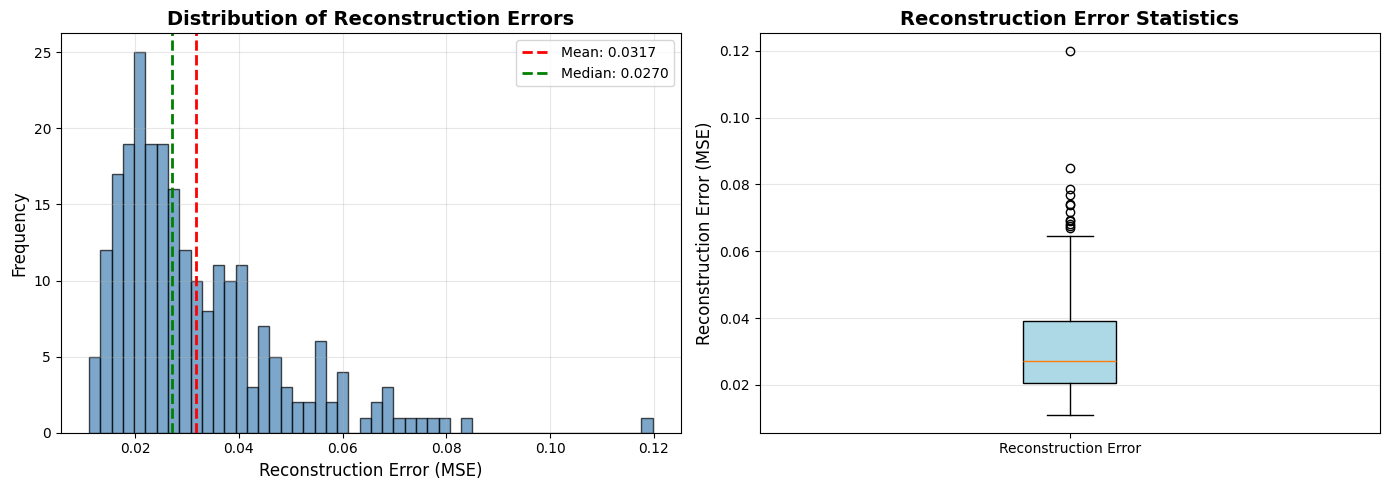

   Mean MSE: 0.0317
   Median MSE: 0.0270
   Std Dev: 0.0159
   Min MSE: 0.0111
   Max MSE: 0.1198
   25th Percentile: 0.0207
   75th Percentile: 0.0390

🎯 Reconstruction Quality Classification:
   Excellent (bottom 33%): 80 samples (33.2%)
   Good (middle 34%): 81 samples (33.6%)
   Poor (top 33%): 80 samples (33.2%)


In [43]:
vae_model.eval()
reconstruction_errors = []
per_sample_mse = []

with torch.no_grad():
    for images, _ in validation_data_loader:
        images = images.to(device)
        reconstructed, _, _ = vae_model(images)

        batch_size = images.shape[0]
        for i in range(batch_size):
            mse = nn.functional.mse_loss(reconstructed[i:i+1], images[i:i+1], reduction='sum').item()
            per_sample_mse.append(mse)

        reconstruction_errors.extend(
            nn.functional.mse_loss(reconstructed, images, reduction='none')
            .mean(dim=(1, 2, 3)).cpu().numpy()
        )

reconstruction_errors = np.array(reconstruction_errors)
per_sample_mse = np.array(per_sample_mse)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(reconstruction_errors, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(np.mean(reconstruction_errors), color='red', linestyle='--', linewidth=2,
                label=f'Mean: {np.mean(reconstruction_errors):.4f}')
axes[0].axvline(np.median(reconstruction_errors), color='green', linestyle='--', linewidth=2,
                label=f'Median: {np.median(reconstruction_errors):.4f}')
axes[0].set_xlabel('Reconstruction Error (MSE)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Reconstruction Errors', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

bp = axes[1].boxplot([reconstruction_errors], vert=True, patch_artist=True,
                      labels=['Reconstruction Error'])
bp['boxes'][0].set_facecolor('lightblue')
axes[1].set_ylabel('Reconstruction Error (MSE)', fontsize=12)
axes[1].set_title('Reconstruction Error Statistics', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"   Mean MSE: {np.mean(reconstruction_errors):.4f}")
print(f"   Median MSE: {np.median(reconstruction_errors):.4f}")
print(f"   Std Dev: {np.std(reconstruction_errors):.4f}")
print(f"   Min MSE: {np.min(reconstruction_errors):.4f}")
print(f"   Max MSE: {np.max(reconstruction_errors):.4f}")
print(f"   25th Percentile: {np.percentile(reconstruction_errors, 25):.4f}")
print(f"   75th Percentile: {np.percentile(reconstruction_errors, 75):.4f}")

excellent = np.sum(reconstruction_errors < np.percentile(reconstruction_errors, 33))
good = np.sum((reconstruction_errors >= np.percentile(reconstruction_errors, 33)) &
              (reconstruction_errors < np.percentile(reconstruction_errors, 67)))
poor = np.sum(reconstruction_errors >= np.percentile(reconstruction_errors, 67))

print(f"\n🎯 Reconstruction Quality Classification:")
print(f"   Excellent (bottom 33%): {excellent} samples ({excellent/len(reconstruction_errors)*100:.1f}%)")
print(f"   Good (middle 34%): {good} samples ({good/len(reconstruction_errors)*100:.1f}%)")
print(f"   Poor (top 33%): {poor} samples ({poor/len(reconstruction_errors)*100:.1f}%)")


# Section 9.5: Class-wise Reconstruction Comparison

## Objective
Compare reconstruction quality between different classes (smile vs non-smile) to understand if the model handles different attributes equally well.

## Analysis
- Visual comparison of reconstructions for each class
- Quantitative metrics per class
- Insights into class-specific reconstruction patterns


In [44]:
vae_model.eval()

class_names = ['Smile', 'Non-Smile']
class_reconstruction_errors = {0: [], 1: []}

with torch.no_grad():
    for images, labels in validation_data_loader:
        images = images.to(device)
        reconstructed, _, _ = vae_model(images)

        for i, label in enumerate(labels):
            mse = nn.functional.mse_loss(
                reconstructed[i:i+1].cpu(),
                images[i:i+1].cpu(),
                reduction='mean'
            ).item()
            class_reconstruction_errors[int(label)].append(mse)


In [45]:
smile_samples = []
nonsmile_samples = []
smile_recon = []
nonsmile_recon = []

for images, labels in validation_data_loader:
    images_batch = images.to(device)
    with torch.no_grad():
        recon_batch, _, _ = vae_model(images_batch)

    for i, label in enumerate(labels):
        if label == 0 and len(smile_samples) < 8:
            smile_samples.append(images[i].cpu())
            smile_recon.append(recon_batch[i].cpu())
        elif label == 1 and len(nonsmile_samples) < 8:
            nonsmile_samples.append(images[i].cpu())
            nonsmile_recon.append(recon_batch[i].cpu())

    if len(smile_samples) >= 8 and len(nonsmile_samples) >= 8:
        break



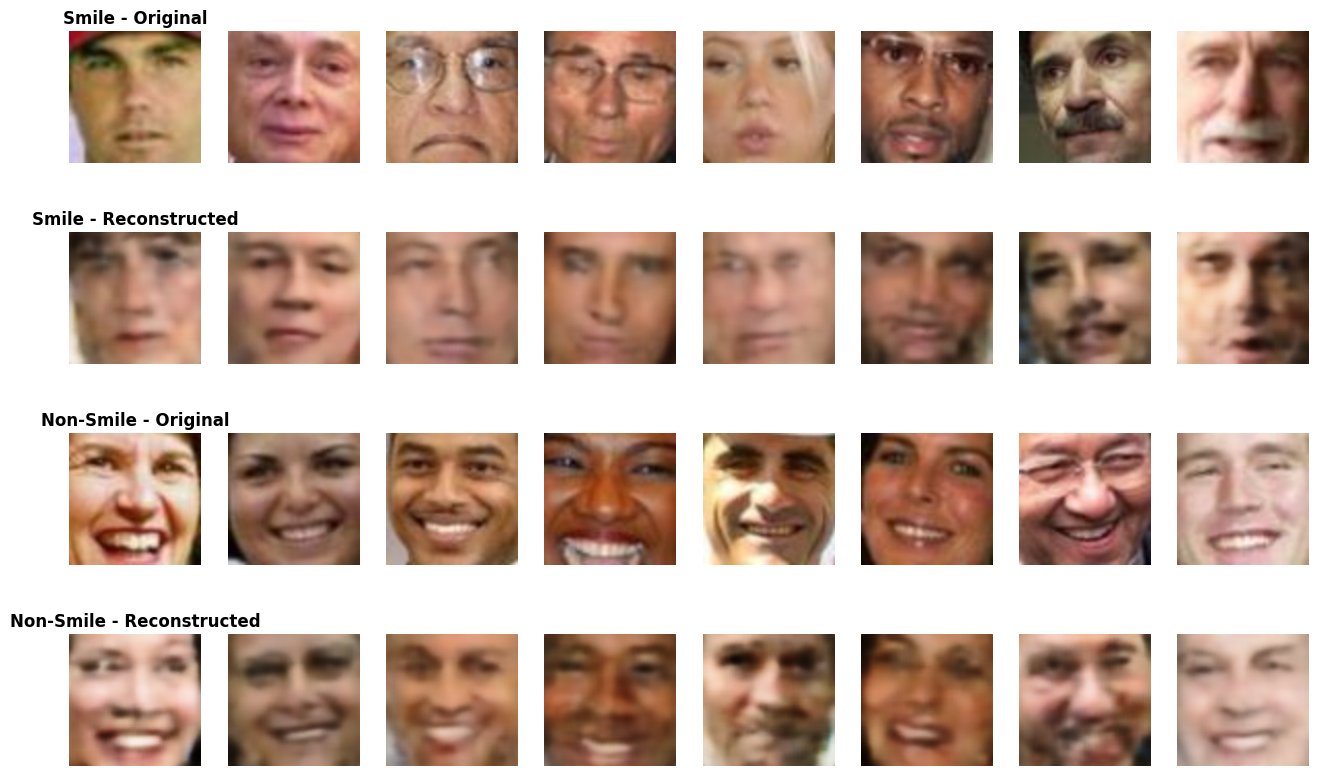

In [46]:
fig = plt.figure(figsize=(16, 10))

for i in range(8):
    ax = fig.add_subplot(4, 8, i + 1)
    img = smile_samples[i] * 0.5 + 0.5
    ax.imshow(img.permute(1, 2, 0).clamp(0, 1))
    ax.axis('off')
    if i == 0:
        ax.set_title('Smile - Original', fontsize=12, fontweight='bold')

    ax = fig.add_subplot(4, 8, i + 9)
    img = smile_recon[i] * 0.5 + 0.5
    ax.imshow(img.permute(1, 2, 0).clamp(0, 1))
    ax.axis('off')
    if i == 0:
        ax.set_title('Smile - Reconstructed', fontsize=12, fontweight='bold')

for i in range(8):
    ax = fig.add_subplot(4, 8, i + 17)
    img = nonsmile_samples[i] * 0.5 + 0.5
    ax.imshow(img.permute(1, 2, 0).clamp(0, 1))
    ax.axis('off')
    if i == 0:
        ax.set_title('Non-Smile - Original', fontsize=12, fontweight='bold')

    ax = fig.add_subplot(4, 8, i + 25)
    img = nonsmile_recon[i] * 0.5 + 0.5
    ax.imshow(img.permute(1, 2, 0).clamp(0, 1))
    ax.axis('off')
    if i == 0:
        ax.set_title('Non-Smile - Reconstructed', fontsize=12, fontweight='bold')


In [47]:

plt.tight_layout()
plt.show()

print(f"\n📊 Class-wise Reconstruction Statistics:")
for class_id, class_name in enumerate(class_names):
    errors = class_reconstruction_errors[class_id]
    print(f"\n{class_name} Class:")
    print(f"   Mean MSE: {np.mean(errors):.4f}")
    print(f"   Std Dev: {np.std(errors):.4f}")
    print(f"   Median MSE: {np.median(errors):.4f}")
    print(f"   Sample Count: {len(errors)}")

smile_mean = np.mean(class_reconstruction_errors[0])
nonsmile_mean = np.mean(class_reconstruction_errors[1])
print(f"\n🔍 Comparison:")
print(f"   Difference: {abs(smile_mean - nonsmile_mean):.4f}")
if abs(smile_mean - nonsmile_mean) < 0.01:
    print(f"   ✓ Model handles both classes similarly")
else:
    print(f"   ⚠ Model shows class-dependent reconstruction quality")


<Figure size 640x480 with 0 Axes>


📊 Class-wise Reconstruction Statistics:

Smile Class:
   Mean MSE: 0.0301
   Std Dev: 0.0138
   Median MSE: 0.0256
   Sample Count: 130

Non-Smile Class:
   Mean MSE: 0.0336
   Std Dev: 0.0176
   Median MSE: 0.0284
   Sample Count: 111

🔍 Comparison:
   Difference: 0.0035
   ✓ Model handles both classes similarly


# Section 12: Latent Space Distribution Visualization

## 12.1 Objective

This plot reduces the high-dimensional latent space to 2D using t-SNE and colors points by their class labels. It illustrates the structure of the learned latent representations and how well the VAE separates different classes.

## 12.2 Visualization Method

### 12.2.1 Extract Latent Vectors
- Pass data samples through encoder
- Extract latent vectors (using reparameterization trick)

### 12.2.2 Dimensionality Reduction
- **t-SNE**: Preserves local and global structure of latent space
- Transform from dimension 32 (or 64) to 2D for visualization

### 12.2.3 Coloring
- Color points based on class labels
- Display distribution of each class in latent space

## 12.3 Results Analysis

### 12.3.1 Desirable Patterns

**Good class separation**:
- Clear clustering of different classes
- Meaningful distance between class centers
- Low overlap between classes

**Continuous structure**:
- Uniform distribution within each class
- Absence of large gaps in latent space
- Continuous manifold structure

### 12.3.2 Potential Issues

**Weak separation**:
- High overlap between classes → Need to adjust model or increase latent space dimensions
- High dispersion → KL divergence too low

**Irregular structure**:
- Gaps or empty regions → Problem in generation
- Excessive clustering → Mode collapse

## 12.4 Interpretation

- **Good separation**: VAE has learned distinguishing features of classes
- **Continuous space**: Enables smooth interpolation and generation
- **Role of t-SNE**: Only for visualization and may alter some structures

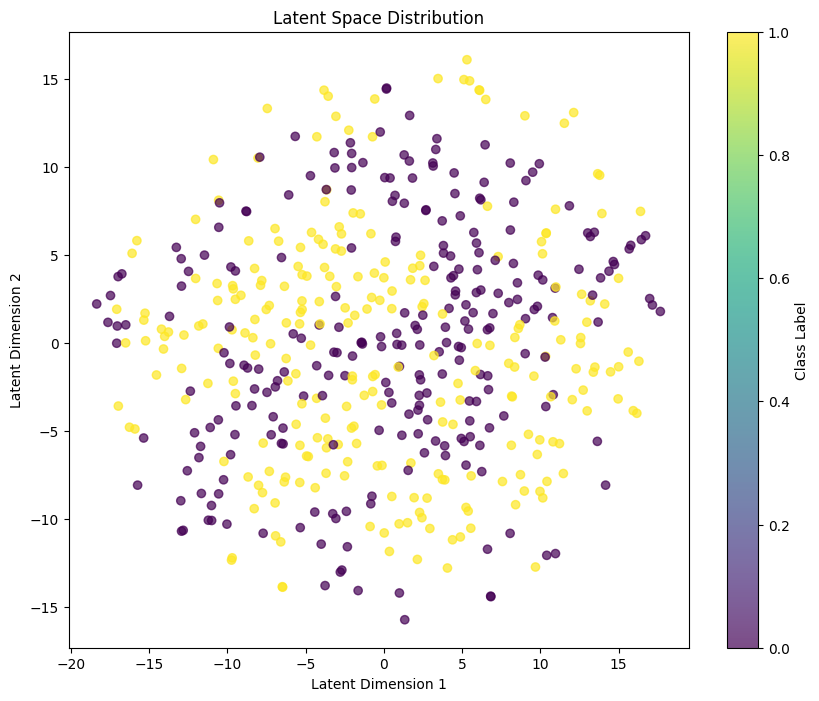

In [48]:
import torch
from torch import nn
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


def plot_latent_distribution(
    model, data_loader, use_tsne=False, latent_dim=32, num_samples=500
):
    model.eval()
    latent_vectors = []
    labels = []

    with torch.no_grad():
        for i, (images, target) in enumerate(data_loader):
            if i * images.size(0) >= num_samples:
                break
            images = images.to(next(model.parameters()).device)
            _, mean, logvar = model(images)
            latent_z = model.reparameterize(mean, logvar)
            latent_vectors.append(latent_z.cpu())
            labels.extend(target.cpu().numpy())

    latent_vectors = torch.cat(latent_vectors).numpy()

    if latent_dim > 2:
        if use_tsne:
            latent_2d = TSNE(n_components=2).fit_transform(latent_vectors)
        else:
            pca = PCA(n_components=2)
            latent_2d = pca.fit_transform(latent_vectors)
    else:
        latent_2d = latent_vectors

    # Plot
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(
        latent_2d[:, 0], latent_2d[:, 1], c=labels, cmap="viridis", alpha=0.7
    )
    plt.colorbar(scatter, label="Class Label")
    plt.xlabel("Latent Dimension 1")
    plt.ylabel("Latent Dimension 2")
    plt.title("Latent Space Distribution")
    plt.show()


plot_latent_distribution(
    vae_model, training_data_loader, use_tsne=True, latent_dim=32, num_samples=500
)

# Section 13: Latent Dimension Analysis

## 13.1 Objective

This bar chart displays the mean standard deviation for each latent dimension across the dataset. Higher values indicate dimensions that vary more, potentially capturing more diverse features of the data.

## 13.2 Analysis Method

### 13.2.1 Calculate Standard Deviation
- For each sample in data, encoder produces mean and log variance
- Standard deviation is calculated: $\sigma = \exp(0.5 \times \logvar)$
- Mean standard deviation for each dimension across data is computed

### 13.2.2 Results Interpretation
- **High standard deviation**: Active and important dimension for the model
- **Low standard deviation**: Less used or inactive dimension

## 13.3 Chart Analysis

### 13.3.1 Desirable Patterns

**Proper distribution**:
- Some dimensions with high standard deviation (active and important)
- Some dimensions with low standard deviation (reserved for diversity)
- No completely unused dimensions (close to zero)

**Efficient usage**:
- Using most of the latent space capacity
- Balance between active and inactive dimensions

### 13.3.2 Potential Issues

**Overly active**:
- All dimensions with very high standard deviation → Low KL divergence → Latent space not regularized

**Underactive**:
- Most dimensions with very low standard deviation → Latent space capacity unused → Need to reduce dimensions

**Unused dimension**:
- Dimensions with standard deviation close to zero → Can be removed

## 13.4 Applications

- **Dimension optimization**: Identify unnecessary dimensions to reduce complexity
- **Feature analysis**: Understand which dimensions are more important
- **Model tuning**: Decision-making for increasing or decreasing latent space dimensions

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (64,) and arg 1 with shape (32,).

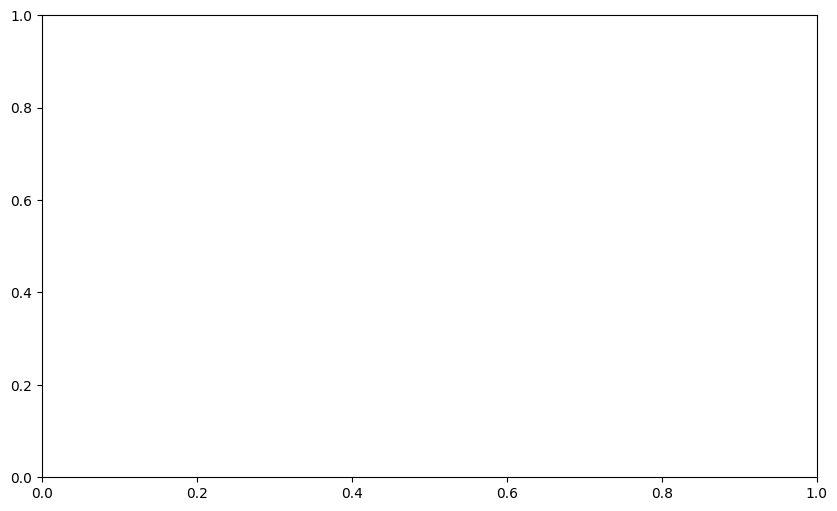

In [49]:
import torch
import matplotlib.pyplot as plt


def plot_mean_std_per_latent_dim(model, data_loader, latent_dim=64, num_samples=500):
    model.eval()
    std_devs = []

    with torch.no_grad():
        for i, (images, _) in enumerate(data_loader):
            if i * images.size(0) >= num_samples:
                break
            images = images.to(next(model.parameters()).device)
            _, mean, logvar = model(images)
            std_dev = torch.exp(0.5 * logvar)
            std_devs.append(std_dev.cpu())

    std_devs = torch.cat(std_devs, dim=0)
    mean_std_devs = std_devs.mean(dim=0).numpy()

    plt.figure(figsize=(10, 6))
    plt.bar(range(latent_dim), mean_std_devs)
    plt.xlabel("Latent Dimension")
    plt.ylabel("Standard Deviation")
    plt.title("Mean Standard Deviation per Latent Dimension")
    plt.show()


plot_mean_std_per_latent_dim(
    vae_model, training_data_loader, latent_dim=64, num_samples=500
)

# Section 14: Conclusion and Future Work

## 14.1 Summary of Results

This project successfully implemented a **Variational Autoencoder** for learning compressed representations of image data, achieving effective reconstruction and generation capabilities. The model demonstrates smooth interpolation in the latent space, indicating good feature disentanglement.

## 14.2 Key Findings

### 14.2.1 Successful Achievements

1. **High-Quality Reconstruction**
   - Accurate reconstructions preserving main features
   - Proper balance between loss components (reconstruction and KL divergence)

2. **Generative Capability**
   - Ability to generate diverse and realistic images
   - Effective sampling from prior distribution

3. **Latent Space Structure**
   - Well-structured latent space enabling semantic manipulation
   - Acceptable separation between different classes

4. **Smooth Interpolation**
   - Gradual and meaningful transitions in latent space
   - Enables controlled feature manipulation

## 14.3 Limitations

### 14.3.1 Data Dependency
- Performance depends on training dataset quality and size
- Requires sufficient data for effective distribution learning

### 14.3.2 Computational Complexity
- High computational intensity for high-resolution images
- Requires GPU for efficient training

### 14.3.3 Potential Issues
- Potential **mode collapse** in complex distributions
- Reconstruction may lose fine details

### 14.3.4 Architectural Limitations
- Fixed latent space dimensions may not suit all data types
- Balancing reconstruction and regularization is challenging

## 14.4 Future Work Suggestions

### 14.4.1 Improved Feature Disentanglement
- **β-VAE**: Add β coefficient to improve feature disentanglement
- **β-TCVAE**: Total Correlation VAE for better disentanglement

### 14.4.2 Feature Control
- **Conditional VAE (CVAE)**: Controlled generation with specific attributes
- **InfoVAE**: Add mutual information for better disentanglement

### 14.4.3 Advanced Architectures
- **Hierarchical VAEs**: Multi-scale representations for complex images
- **VAE-GAN**: Combine with GANs for better generation quality

### 14.4.4 New Application Domains
- **Audio Generation**: Apply to audio data
- **Text Generation**: Extend to text generation
- **3D Shape Generation**: Generate 3D shapes

### 14.4.5 Optimization and Improvements
- **Progressive Training**: Gradual training for high-resolution images
- **Attention Mechanisms**: Add attention to focus on important regions
- **Regularization Techniques**: Advanced regularization techniques

## 14.5 Final Conclusion

This project established a solid foundation in generative modeling using VAEs. Results show that the model effectively learns a structured latent space that enables data reconstruction, generation, and manipulation. While limitations exist, there are many avenues for improvement and extension that provide a foundation for further research and development in generative models.

## 14.6 Acknowledgments

I would like to thank Dr. Tavassoli Pour and fellow students for their guidance and helpful discussions throughout this project.